# Predicción de incendios en la Patgaonia Andina.

**Autor:** Claudio Ezequiel Villagra Turco  
**Institución:** Universidad Nacional Guillermo Brown (UNaB)  
**Fecha:** Q4 2025  
**Correo electrónico:** ezequiel26.92@gmail.com 

---

## Resumen



---

## 1. Introducción

### 1.1. Contexto y Justificación
Por medio de esta investigación se busca abordar el fenómeno de incendios forestales en la Patagonia Andina a partir de un enfoque basado en la recopilación de datos. A continuación, se establecen los objetivos que darán lugar al desarrollo del trabajo, orientados tanto a la comprensión de los factores asociados a la aparición de focos de calor como al diseño de herramientas que permitan su detección y predicción.


### 1.2. Objetivos
#### 1.2.1. Objetivo General
Estudiar y comprender los incendios forestales de la Patagonia Andina que tienen lugar durante epocas de verano analizando los factores determinantes, evaluando su relación con la ocurrencia de incendios y explorar su potencial en la construcción de modelos predictivos.

#### 1.2.2. Objetivos Específicos
1. Recopilar y sistematizar la información necesaria y disponible para el desarrollo del proyecto, incluyendo datos satelitales, climatológicos y ambientales.
2. Realizar un análisis exploratorio de los datos recopilados para identificar patrones y correlaciones entre las variables estudiadas y la ocurrencia de incendios.
3. Implementar modelos de Machine Learning que permitan identificar focos activos y predecir la probabilidad de nuevos focos en una región específica.
4. Evaluar la efectividad de los modelos desarrollados mediante la comparación de sus predicciones con datos históricos de incendios.


## 2. Preparación


### 2.1 - Configuración de entorno.

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import logging
import xarray as xr


import matplotlib.pyplot as plt
# import seaborn as sns
# import geopandas as gpd

sys.path.append('../scripts')

from datetime import datetime
# from tqdm import tqdm
from project_config import ProjectConfig as cfg


## 3. Desarrollo


### 3.1 - Recopilación y sistematización de la información.


#### 3.1.1 - Articulos de Interés

- [Este articulo oficial](https://nahuelhuapi.gov.ar/focos-de-incendio-en-la-zona-de-lago-los-manzanos-en-cercanias-a-lago-martin/) es el primer reporte de detección de incendio emitido por las autoridades del Parque Nacional Nahuel Huapi el Jueves 26 de diciembre del 2024.

- [Este articulo periodistico](https://www.diarioandino.com.ar/noticias/2024/12/28/229751-el-incendio-en-el-lago-martin-ya-arraso-mas-de-1450-hectareas-de-bosque-nativo) evidencia la escalada del fuego en la zona sólo en los primeros 3 días desde su inicio, corresponde al Sábado 28 de diciembre del 2024.

- [Esta sección](https://confluence.ecmwf.int/display/CKB/ERA5%3A+What+is+the+spatial+reference) de la base de conocimiento de Copernicus tiene información acerca del sistema de coordenadas y una recomendación para la interpolacion de los datos.


#### 3.1.2 - Focos de Incendio (NASA FIRMS)

In [ ]:
from firms_tools import FIRMSTools

Mediante las FIRMSTools se puede hacer la descarga de datos que representan puntos de la región de estudio (la cual se encuentra configurada en project_config.py) donde se ha detectado un foco de incendio luego del pre-procesamiento de los datos de satelite.

La fución recibe las fuentes que están disponibles en el web service de la NASA son:
- ALL - all available sensors
- LANDSAT_NRT (LANDSAT 8/9)
- MODIS_NRT (MODIS Near Real-Time)
- MODIS_SP (MODIS Standard Processing) - [Descripción](https://www.earthdata.nasa.gov/data/catalog/lancemodis-mcd14dl-6.1nrt#ed-firms-attributes) || [Guía de usuario](https://www.earthdata.nasa.gov/sites/default/files/imported/MODIS_C6_Fire_User_Guide_B.pdf)
- VIIRS_NOAA20_NRT (VIIRS NOAA-20 Near Real-Time)
- VIIRS_NOAA20_SP (VIIRS NOAA-20 Standard Processing) - [Descripción](https://www.earthdata.nasa.gov/data/catalog/lancemodis-vj114imgtdl-nrt-2)
- VIIRS_NOAA21_NRT (VIIRS NOAA-21 Near Real-Time)
- VIIRS_SNPP_NRT (VIIRS Suomi-NPP Near Real-Time)
- VIIRS_SNPP_SP (VIIRS Suomi-NPP Standard Processing) - [Descripción](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/viirs/)

Para este estudio se obtendrá información ya procesada (SP) dado que no aportaría valor acceder a información en tiempo real (NRT).

In [ ]:
# Obtención de datos en bruto desde FIRMS.
get_from_sources = ['MODIS_SP', 'VIIRS_NOAA20_SP', 'VIIRS_SNPP_SP']
firms = FIRMSTools()
raw_data = firms.get_fire_data(get_from_sources)

En [este enlace](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs) se puede acceder al detalle de los atributos para cada fuente de información.


#### 3.1.3 - Información meteorologíca. (COPERNICUS LAND Y LEVELS)

In [ ]:
from copernicus_tools import CopernicusTools


##### 3.1.3.1 - Copernicus ERA5 Levels

Utilizando CopernicusTools se puede acceder a los datos provistos por el programa de observación terrestsre (Copernicus) de la Union Europea. Está información se obtendrá haciendo uso de la API provista por el CDS ([Climate Data Storage](https://cds.climate.copernicus.eu/)).

ERA5 proporciona estimaciones horarias de una gran cantidad de variables climáticas atmosféricas, terrestres y oceánicas. Los datos cubren la Tierra en una cuadrícula de 31 km y resuelven la atmósfera utilizando 137 niveles desde la superficie hasta una altura de 80 km. ERA5 incluye información sobre las incertidumbres de todas las variables con resoluciones espaciales y temporales reducidas. Utilice [este enlace](https://confluence.ecmwf.int/display/CKB/The+family+of+ERA5+datasets) para acceder a toda la documentación relevante.

In [ ]:
copernicus = CopernicusTools()
file = copernicus.get_meteorological_data('levels')
df_clima = file.to_dataframe().reset_index()

In [ ]:
df_clima.to_csv(f"{cfg.DATA_RAW}/copernicus/levels/{cfg.START_DATE}_{cfg.END_DATE}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index = False)


##### 3.1.3.2 - Copernicus ERA5 Land

In [ ]:
def ProcesamientoLand(path):
    """Procesa todos los meses incluyendo todos los steps/horarios.
    Está función debe ser trasladada al script de copernicus_tools.py
    y ser llamada desde aquí.
    """
    
    meses = ['Diciembre', 'Enero', 'Febrero', 'Marzo']
    dataframes = []
    
    for mes in meses:
        ruta_mes = f"{path}/{mes}/data.grib"
        print(f"\n Procesando {mes}...")
        
        try:
            ds = xr.open_dataset(ruta_mes, engine = 'cfgrib', filter_by_keys = {'edition': 1})
            df_mes = ds.to_dataframe().reset_index()
            dataframes.append(df_mes)
        except Exception as e:
            print(f"Error en {mes}: {e}")
    
    if dataframes:
        df_completo = pd.concat(dataframes, ignore_index = True)
        df_completo = df_completo.sort_values(['time', 'step', 'latitude', 'longitude']).reset_index(drop = True)
        
        print(f"\n DATASET COMPLETO CON TODOS LOS STEPS: {len(df_completo)} filas")
        print(f"Período total: {df_completo['time'].min()} a {df_completo['time'].max()}")
        print(f"Steps/horarios incluidos: {df_completo['step'].nunique()}")
        print(f"Estructura final: {len(df_completo)} filas × {len(df_completo.columns)} columnas")
        
        return df_completo
    else:
        print("No se pudo cargar ningún mes")
        return None

df_copernicus_land = ProcesamientoLand(f'{cfg.DATA_RAW}/copernicus/land')

In [ ]:
to_drop = [
    'time',
    'number',
    'step',
    'surface'
]

df_copernicus_land = df_copernicus_land.iloc[363:58927,:]
df_copernicus_land = df_copernicus_land.drop(to_drop, axis = 1)
df_copernicus_land = df_copernicus_land.rename(columns = {'valid_time' : 'acq_datetime'})

df_copernicus_land.to_csv(f"{cfg.DATA_RAW}/copernicus/land/land_{cfg.START_DATE}_{cfg.END_DATE}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index = False)

A estas alturas se ha conseguido la siguiente información:
- Focos de incendio en resolución espacial en: 1km, 0.375km
- Información meteorologica en: 25km

Problema: el nivel de datalle obtenido desde FIRMS no se coincide con el de Copernicus, para lograr un conjunto de datos donde la información de estas fuentes y aquellas a obtener se debe determinar la estrategía de unificación de datos.



1. Tomar como base el conjunto de datos meteorologícos, para cada foco de calor etiquetado por NASA, asignarlo a la celda de información ERA5. Sin embargo, el BBOX utilizado sólo devuelve una grilla del tipo 1x2 (25kms x 50kms) por ende quedarían dos zonas separadas dentro del área de estudio que compartirián caracteristicas meteorologicas similares y cantidad de focos de incendio con su respectiva información de FRP y brillo.

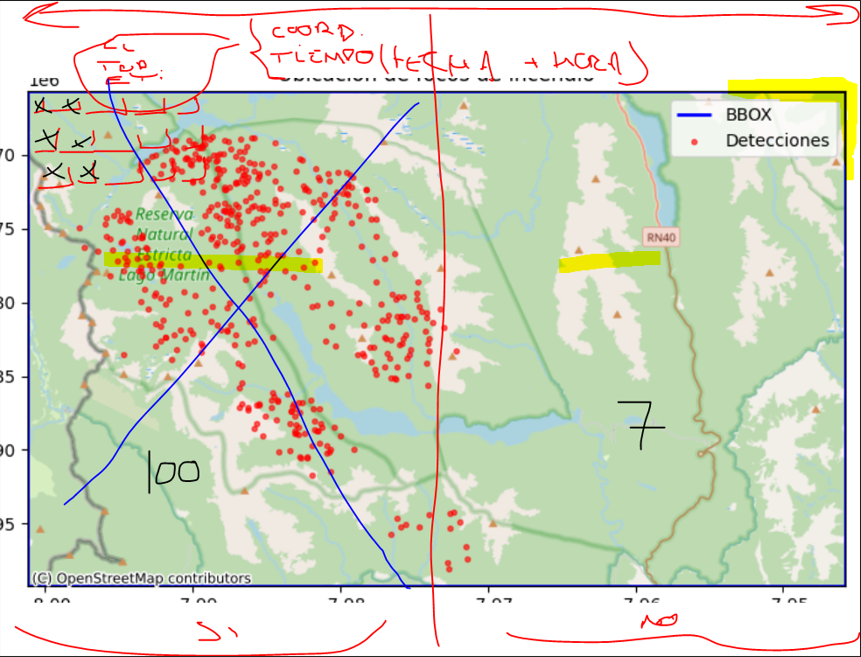

Esto implicaria perder el detalle que se obtiene desde VIIRS dado el traslado de sus datos de 375m a una escala de 25km, pero se aseguraria tener las variables climáticas que son el objeto de estudio para la predicción.


2. Llevar los datos meteorologícos a un grilla que se adapte a los focos de calor, está estrategía no mejoraría los datos de cara a la implementación de los modelos, dado que para cada foco, por ejemplo en la longitud oeste de la imagén de arriba, todos los focos tendrían las mismas condiciones climatologicas. Sin embargo, se podrían utilizar los métodos de interpolación y vecinos cercanos que expone Copernicus en su documentación.




### 3.2 - Tratamiento de datos.


#### 3.2.1 - Meteorologicos

In [8]:
df_clima = pd.read_csv(f"{cfg.DATA_RAW}/copernicus/land/land_2024-12-01_2025-03-31_20251004_184357.csv")

In [9]:
df_clima.columns

Index(['latitude', 'longitude', 'acq_datetime', 'd2m', 't2m', 'fal', 'slhf',
       'ssr', 'str', 'sshf', 'ssrd', 'strd', 'e', 'u10', 'v10', 'sp', 'tp',
       'lai_hv', 'lai_lv'],
      dtype='object')

Caracteristicas del conjunto de datos:
- **d2m**: *Temperatura del punto de rocío a 2m* se calcula interpolando entre el nivel más bajo del modelo y la superficie terrestre, considerando las condiciones atmosféricas. Este parámetro se mide en kelvin (K). La temperatura medida en kelvin se puede convertir a grados Celsius (°C) restando 273,15.
  
- **t2m**: *Temperatura del aire a 2m* sobre la superficie terrestre, marina o de aguas continentales. Se calcula interpolando entre el nivel más bajo del modelo y la superficie terrestre, considerando las condiciones atmosféricas. La temperatura medida en kelvin se puede convertir a grados Celsius (°C) restando 273,15.
  
- **fal**: *Forecast albedo* es una medida de la reflectividad de la superficie terrestre. Es la fracción de radiación solar (de onda corta) reflejada por la superficie terrestre, a lo largo del espectro solar, tanto para la radiación directa como para la difusa.  Unidad de medida: Los valores oscilan entre 0 y 1.
  
- **slhf**: *Surface latent heat net flux (flujo neto de calor latente superficial)* representa la transferencia de calor latente (resultante de los cambios de fase del agua, como la evaporación o la condensación) entre la superficie terrestre y la atmósfera mediante el movimiento turbulento del aire. La evaporación de la superficie terrestre representa una transferencia de energía de la superficie a la atmósfera. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.
  
- **ssr**: *Surface net short-wave (solar) radiation* es la cantidad de radiación solar (también conocida como radiación de onda corta) que llega a un plano horizontal en la superficie de la Tierra (tanto directa como difusa) menos la cantidad reflejada por la superficie de la Tierra (que está gobernada por el albedo). Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **str**: *Surface net thermal radiation (Radiación térmica neta superficial)* es la radiación térmica (también conocida como radiación de onda larga o terrestre) y se refiere a la radiación emitida por la atmósfera, las nubes y la superficie terrestre. Este parámetro es la diferencia entre la radiación térmica descendente y ascendente en la superficie terrestre. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **sshf**: *Surface sensible heat net flux (flujo neto de calor sensible superficial)* representa la transferencia de calor entre la superficie terrestre y la atmósfera mediante el movimiento turbulento del aire (excluyendo la transferencia de calor resultante de la condensación o la evaporación). La magnitud del flujo de calor sensible se rige por la diferencia de temperatura entre la superficie y la atmósfera suprayacente, la velocidad del viento y la rugosidad de la superficie. Por ejemplo, el aire frío sobre una superficie cálida produciría un flujo de calor sensible desde la tierra (o el océano) hacia la atmósfera. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **ssrd**: *Surface short-wave (solar) radiation downwards (radiación superficial de onda corta (solar) hacia abajo)* es la cantidad de radiación solar (también conocida como radiación de onda corta) que alcanza un plano horizontal en la superficie terrestre. Este parámetro comprende tanto la radiación solar directa como la difusa. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **strd**: *Surface long-wave (thermal) radiation downwards (radiación superficial de onda larga (térmica) hacia abajo)* es la cantidad de radiación térmica (también conocida como de onda larga o terrestre) emitida por la atmósfera y las nubes que llega a un plano horizontal en la superficie de la Tierra. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **e**: *Evaporation (evaporación)* es la cantidad acumulada de agua que se ha evaporado de la superficie de la Tierra, incluida una representación simplificada de la transpiración (de la vegetación), en vapor en el aire de arriba. Unidad de medida: m de agua equivalente.

- **u10**: *Componente de viento U de 10 metros* representa la componente este del viento de 10m. Es la velocidad horizontal del aire que se desplaza hacia el este, a una altura de diez metros sobre la superficie terrestre, en metros por segundo. Se debe tener cuidado al comparar este parámetro con las observaciones, ya que estas varían en escalas espaciales y temporales pequeñas y se ven afectadas por el terreno, la vegetación y los edificios locales, que solo se representan en promedio en el Sistema Integrado de Pronóstico del ECMWF. Este parámetro puede combinarse con la componente V del viento de 10m para obtener la velocidad y la dirección del viento horizontal de 10m. Unidad de medida: m/s.

- **v10**: *Componente de viento V de 10 metros* representa la componente norte del viento de 10m. Es la velocidad horizontal del aire que se desplaza hacia el norte, a una altura de diez metros sobre la superficie terrestre, en metros por segundo. Se debe tener cuidado al comparar este parámetro con las observaciones, ya que estas varían en escalas espaciales y temporales pequeñas y se ven afectadas por el terreno, la vegetación y los edificios locales, que solo se representan en promedio en el Sistema Integrado de Pronóstico del ECMWF. Este parámetro puede combinarse con la componente U del viento de 10m para obtener la velocidad y la dirección del viento horizontal de 10m. Unidad de medida: m/s.

- **sp**: *Presión superficial* representa la presión (fuerza por unidad de área) de la atmósfera sobre la superficie terrestre, marina y de aguas continentales. Es una medida del peso de todo el aire en una columna vertical sobre el área de la superficie terrestre representada en un punto fijo. La presión superficial se utiliza a menudo **en combinación con la temperatura para calcular la densidad del aire**. La fuerte variación de la presión con la altitud dificulta la visualización de los sistemas de baja y alta presión en zonas montañosas, por lo que se suele utilizar la presión media a nivel del mar, en lugar de la presión superficial, para este propósito. Unidad de medida: pascales (Pa), la presión superficial se suele medir en hPa y, a veces, se presenta en las antiguas unidades de milibares, mb (1 hPa = 1 mb = 100 Pa).

- **tp**: *Precipitación total* corresponde al agua líquida y congelada acumulada, compuesta por lluvia y nieve, que cae sobre la superficie terrestre. Es la suma de la precipitación a gran escala y la precipitación convectiva. Representa la cantidad total de agua acumulada durante un período determinado, que depende de los datos extraídos. Unidad de medida: metros.

- **lai_hv**: *Índice de área foliar, vegetación alta* representa la superficie de un lado de todas las hojas presentes en un área de terreno para la vegetación clasificada como "alta". Este parámetro tiene un valor de 0 en terrenos desnudos o donde no hay hojas. La "vegetación alta" incluye árboles de hoja perenne, árboles de hoja caduca, bosques mixtos y bosques interrumpidos. Unidad de medida: m^2.

- **lai_lv**: *Índice de área foliar, vegetación baja* representa la superficie de un lado de todas las hojas presentes en un área de terreno para la vegetación clasificada como "baja". Este parámetro tiene un valor de 0 en terrenos desnudos o sin hojas. La "vegetación baja" incluye cultivos y agricultura mixta, cultivos de regadío, pastos cortos, pastos altos, tundra, semidesiertos, turberas y marismas, arbustos perennes, arbustos caducifolios y mezclas de agua y tierra. Unidad de medida: m^2.

In [ ]:
df_clima.shape

In [10]:
df_clima.head()

,latitude,longitude,acq_datetime,d2m,t2m,fal,slhf,ssr,str,sshf,ssrd,strd,e,u10,v10,sp,tp,lai_hv,lai_lv
0,-42.0,-72.0,2024-12-01 18:00:00,271.39783,280.30920,0.378664,-2185320.0,9660288.0,-1488520.0,-3042780.0,15559688.0,19661316.0,-0.000854,2.608597,0.662735,91121.06,0.009006,4.293335,1.942749
1,-42.0,-71.9,2024-12-01 18:00:00,271.45250,280.77600,0.383013,-2272268.0,9640990.0,-1694153.0,-2722692.0,15636152.0,19475380.0,-0.000888,2.645706,0.553360,91435.06,0.008235,4.253540,2.719116
2,-42.0,-71.8,2024-12-01 18:00:00,270.42126,280.24475,0.341662,-2878472.0,10419402.0,-1965970.0,-3335776.0,15832232.0,19244856.0,-0.001126,2.722855,0.450821,89774.06,0.007506,4.149658,2.783081
3,-42.0,-71.7,2024-12-01 18:00:00,270.54430,281.97717,0.211672,-4578260.0,12630782.0,-2737790.0,-4941300.0,16028716.0,19014280.0,-0.001821,2.800980,0.348282,90593.06,0.006777,3.712036,2.792847
4,-42.0,-71.6,2024-12-01 18:00:00,271.01697,283.53577,0.142123,-5948724.0,13966438.0,-3438949.0,-5148248.0,16315828.0,18763920.0,-0.002378,2.955277,0.365860,91799.06,0.005983,3.943970,2.691284



##### 3.2.1.1 - Fire Weather Index (FWI)

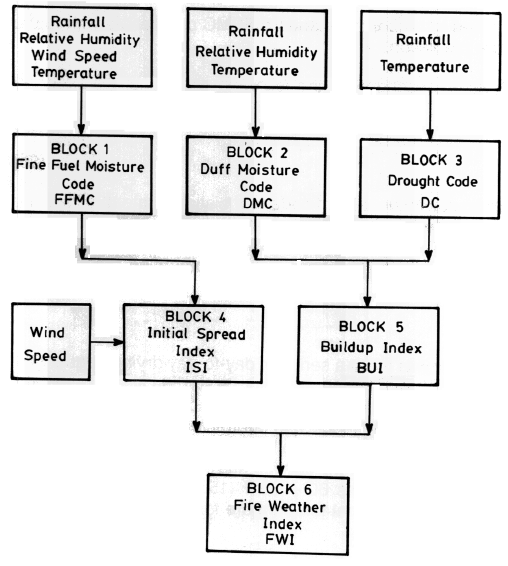

In [ ]:
def kelvin_a_celsius(value):
    """
    Convierte una temperatura de Kelvin a Celsius. 
    
    Parámetros:
    value: Temperatura en Kelvin.

    Retorna:
    Temperatura en Celsius.
    """
    return value - 273.15

def conversion_kelvin(df, cols = ['t2m', 'd2m']):
    """
    Convierte las columnas de temperatura de Kelvin a Celsius en un DataFrame.
    
    Parámetros:
    df: DataFrame con columnas 't2m' y 'd2m' en Kelvin.

    Retorna:
    DataFrame con las columnas 't2m' y 'd2m' convertidas a Celsius.
    """
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype('float64') - 273.15
    return df

def humedad_relativa(temperature, dew_point):
    """
    Calcula la humedad relativa a partir de la temperatura y el punto de rocío.
    
    Parámetros:
    temperature: Temperatura en grados Celsius.
    dew_point: Punto de rocío en grados Celsius.
    
    Retorna:
    Humedad relativa en porcentaje.
    """

    a = 17.625
    b = 243.04
    num = np.exp((a * dew_point) / (b + dew_point))
    den = np.exp((a * temperature) / (b + temperature))
    rh = 100.0 * (num / den)

    rh = np.clip(rh, 0.0, 100.0)
    return rh

def viento_vel_dir(u, v):
    """
    Calcula la velocidad y dirección del viento a partir de componentes u y v.
    
    Parámetros:
    u (ERA5 notation: u-component of wind): componente zonal del viento (m/s).
    v (ERA5 notation: v-component of wind): componente meridional del viento (m/s).

    Retorna:
    vel: velocidad del viento (m/s).
    dir: dirección del viento (grados desde el norte).
    """
    vel = np.sqrt(np.asarray(u) ** 2 + np.asarray(v) ** 2) # Función pitágoras.
    dir_deg = (np.degrees(np.arctan2(np.asarray(v), np.asarray(u))) + 360) % 360 # Función arcotangente.
    return vel, dir_deg

def calcular_precipitacion(group, tp_col = 'tp_mm', time_col = 'acq_datetime'):
    """
    Calcula la precipitación por intervalo a partir de la precipitación acumulada.
    
    Parámetros:
    group : Grupo de datos con columna 'tp_mm' (precipitación acumulada en mm)
    
    Retorna:
    Serie con precipitación por intervalo en mm, alineada al índice del grupo.
    """
    tp = group[tp_col].astype('float64')
    
    if time_col in group.columns:
        tp = tp.sort_index() if False else tp
    diff = tp.diff()
    
    diff.iloc[0] = tp.iloc[0]
    
    mask_neg = diff < 0
    if mask_neg.any():
        diff.loc[mask_neg] = tp.loc[mask_neg]
    
    diff = diff.clip(lower=0.0)
    return diff

def aplicar_precipitacion(df, columna_acumulada = 'tp', tp_mm_col = 'tp_mm', out_col = 'precipitacion_mm',
                          group_cols = ['latitude','longitude'], time_col = 'acq_datetime'):
    """
    Función que calcula la precipitación por intervalo a partir de la acumulada, agrupando por punto espacial.

    Paramétros:
    df: DataFrame con columna de precipitación acumulada en metros (columna_acumulada).
    columna_acumulada: nombre de la columna con precipitación acumulada en metros (default 'tp').
    tp_mm_col: nombre de la columna temporal para precipitación acumulada en mm (default 'tp_mm').
    out_col: nombre de la columna de salida con precipitación por intervalo en mm (default 'precipitacion_mm').
    group_cols: columnas para agrupar por punto espacial (default ['latitude','longitude']).
    time_col: columna de tiempo para ordenar dentro de cada grupo (default 'acq_datetime').

    Retorna:
    DataFrame con columna adicional de precipitación por intervalo en mm (out_col).
    """
    df = df.copy()
    # Convertir m a mm
    if columna_acumulada not in df.columns:
        raise KeyError(f"columna acumulada '{columna_acumulada}' no encontrada en df")
    df[tp_mm_col] = df[columna_acumulada].astype('float64') * 1000.0

    # Asegurar columna de tiempo tipo datetime
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])

    # Array vacío para resultados
    resultado = pd.Series(index = df.index, dtype = 'float64')

    # Agrupar por lat/lon
    groupby_obj = df.groupby(group_cols, sort = False)

    for _, group_idx in groupby_obj.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        precip_interval = calcular_precipitacion(group, tp_col = tp_mm_col, time_col = time_col)
        resultado.loc[precip_interval.index] = precip_interval

    df[out_col] = resultado
    df[out_col] = df[out_col].fillna(0.0)
    return df

def calcular_ffmc(temperature, rh, wind_speed, precipitation, previous_ffmc = 85.0):
    """
    Calcula el Fine Fuel Moisture Code (FFMC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    rh : Humedad relativa en %
    wind_speed : Velocidad del viento en m/s (se convierte a km/h)
    precipitation : Precipitación en mm
    previous_ffmc : FFMC del día anterior (default=85.0)
    
    Retorna:
    ffmc : Fine Fuel Moisture Code

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Fine+fuel+moisture+code
    """
    if any(pd.isna([temperature, rh, wind_speed, precipitation])):
        return previous_ffmc

    wind_speed_kmh = wind_speed * 3.6
    
    m0 = 147.2 * (101.0 - previous_ffmc) / (59.5 + previous_ffmc)

    # Efecto de la lluvia.
    if precipitation > 0.5:
        rf = precipitation - 0.5        
        if m0 <= 150.0:
            m0 += 42.5 * rf * np.exp(-100.0 / (251.0 - m0)) * (1.0 - np.exp(-6.93 / rf))
        else : 
            m0 += 42.5 * rf * np.exp(-100.0 / (251.0 - m0)) * (1.0 - np.exp(-6.93 / rf)) + 0.0015 * (m0 - 150.0) ** 2 * np.sqrt(rf)
        m0 = min(m0, 150.0)

    # Efecto del secado (temperatura, humedad, viento).
    # Humedad de equilibrio por secado (Ed) y por humectación (Ew).
    Ed = 0.942 * (rh**0.679) + 11.0 * np.exp((rh - 100.0) / 10.0) + \
         0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))
    
    Ew = 0.618 * (rh**0.753) + 10.0 * np.exp((rh - 100.0) / 10.0) + \
         0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))

    # Lógica de secado/humectación
    if m0 > Ed:
        # Secado
        k0 = 0.424 * (1.0 - (rh / 100.0) ** 1.7) + \
             0.0694 * np.sqrt(wind_speed_kmh) * (1.0 - (rh / 100.0) ** 8)
        kd = k0 * 0.581 * np.exp(0.0365 * temperature)
        m = Ed + (m0 - Ed) / (10.0 ** kd)
    elif m0 < Ew:
        # Humectación
        k1 = 0.424 * (1.0 - ((100.0 - rh) / 100.0) ** 1.7) + \
             0.0694 * np.sqrt(wind_speed_kmh) * (1.0 - ((100.0 - rh) / 100.0) ** 8)
        kw = k1 * 0.581 * np.exp(0.0365 * temperature)
        m = Ew - (Ew - m0) / (10.0 ** kw)
    else:
        m = m0

    # FFMC
    ffmc = (59.5 * (250.0 - m)) / (147.2 + m)
    
    return np.clip(ffmc, 0.0, 101.0)

def calcular_ffmc_series(df, ffmc0 = 85.0, group_cols = ['latitude','longitude'],
                         time_col = 'acq_datetime', temp_col = 't2m', rh_col = 'humedad_relativa',
                         wind_col = 'wind_speed', precip_col = 'precipitacion_mm'):
    """
    Calcula FFMC por punto espacial (group_cols), preservando la secuencia temporal.
    
    Parámetros:
    df: DataFrame con columnas de temperatura, humedad relativa, velocidad del viento y precipitación
    ffmc0: valor inicial de FFMC (default=85.0)
    group_cols: columnas para agrupar por punto espacial (default ['latitude','longitude'])
    time_col: columna de tiempo para ordenar dentro de cada grupo (default 'acq_datetime')
    temp_col: columna de temperatura en °C (default 't2m')
    rh_col: columna de humedad relativa en % (default 'humedad_relativa')
    wind_col: columna de velocidad del viento en m/s (default 'wind_speed')
    precip_col: columna de precipitación en mm (default 'precipitacion_mm')

    Retorna:
    Serie con valores de FFMC, alineada al índice del DataFrame original.
    """
    
    ffmc_result = pd.Series(index = df.index, dtype = 'float64')

    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = ffmc0
        vals = []
        for i, row in group.iterrows():
            prev = calcular_ffmc(
                temperature = row[temp_col],
                rh = row[rh_col],
                wind_speed = row[wind_col],
                precipitation = row[precip_col],
                previous_ffmc = prev
            )
            vals.append(prev)
        ffmc_result.loc[group.index] = vals
    ffmc_result = ffmc_result.fillna(ffmc0)
    return ffmc_result

def calcular_dmc(temperature, rh, precipitation, previous_dmc = 6.0, month = 12):
    """
    Calcula el Duff Moisture Code (DMC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    rh : Humedad relativa en %
    precipitation : Precipitación en mm
    previous_dmc : DMC del día anterior (default=6.0)
    month : Mes del año (1-12) para ajuste estacional (default=7)
    
    Retorna:
    dmc : Duff Moisture Code

    Ver: https://wikifire.wsl.ch/tiki-index9436.html?page=Duff+moisture+code
    """
    # Factores de longitud del día para hemisferio sur (horas de luz aproximadas).
    day_length_factors = np.array([
        14.5, 13.92, 12.92, 11.92, 10.50, 9.30,
        9.50, 10.58, 11.92, 13.02, 14.03, 15.08
    ])
    day_length_adjustment = day_length_factors[int(month) - 1]

    dmc = previous_dmc

    # Efecto lluvia.
    if precipitation > 1.5 :
        re = 0.92 * precipitation - 1.27
        mo = 20.0 + np.exp(5.6348 - dmc / 43.43)
        if dmc <= 33.0 :
            b = 100.0 / (0.5 + 0.3 * dmc)
        elif dmc <= 65.0:
            b = 14.0 - 1.3 * np.log(dmc)
        else :
            b = 6.2 * np.log(dmc) - 17.2
        mr = mo + 1000.0 * re / (48.77 + b * re)
        dmc = 244.72 - 43.43 * np.log(mr - 20.0)
        dmc = max(dmc, 0.0)

    # Efecto temperatura y humedad.
    temp_adj = max(temperature, -1.1)
    k = 1.894 * (temp_adj + 1.1) * (100.0 - rh) * day_length_adjustment * 1e-4
    dmc = dmc + k
    dmc = max(dmc, 0.0)
    return dmc

def calcular_dmc_series(df, initial_dmc = 6.0, group_cols = ['latitude','longitude'],
                        time_col = 'acq_datetime', temp_col = 't2m', rh_col = 'humedad_relativa',
                        precip_col = 'precipitacion_mm', month_col = None):
    """
    Versión vectorizada para cálculo de DMC por punto espacial.
    
    Parámetros:
    df: DataFrame con columnas de temperatura, humedad relativa y precipitación
    initial_dmc: valor inicial de DMC (default=6.0)
    group_cols: columnas para agrupar por punto espacial (default ['latitude','longitude'])
    time_col: columna de tiempo para ordenar dentro de cada grupo (default 'acq_datetime
    temp_col: columna de temperatura en °C (default 't2m')
    rh_col: columna de humedad relativa en % (default 'humedad_relativa')
    precip_col: columna de precipitación en mm (default 'precipitacion_mm')
    month_col: nombre de la columna con el mes (1..12). Si None, se infiere desde time_col.

    Retorna:
    Serie con valores de DMC, alineada al índice del DataFrame original.
    """
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
    if month_col is None and time_col in df.columns:
        df['__month_inferred__'] = df[time_col].dt.month
        month_col = '__month_inferred__'

    dmc_result = pd.Series(index=df.index, dtype='float64')

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = initial_dmc
        vals = []
        for i, row in group.iterrows():
            month = int(row[month_col]) if month_col in row.index else 12
            prev = calcular_dmc(
                temperature = row[temp_col],
                rh = row[rh_col],
                precipitation = row[precip_col],
                previous_dmc = prev,
                month = month
            )
            vals.append(prev)
        dmc_result.loc[group.index] = vals

    dmc_result = dmc_result.fillna(initial_dmc)
    # limpiar columna temporal si la creamos
    if '__month_inferred__' in df.columns:
        df.drop(columns='__month_inferred__', inplace=True, errors=True)
    return dmc_result

def calcular_dc(temperature, precipitation, previous_dc = 15.0, month = 12):
    """
    Calcula el Drought Code (DC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    precipitation : Precipitación en mm
    previous_dc : DC del día anterior (default = 15.0)
    month : Mes del año (1-12) para ajuste estacional (default = 12)
    
    Retorna:
    dc : Drought Code

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Drought+code
    """
    day_length_factors = np.array([
        -1.6, -1.6, -1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4, -1.6, -1.6
    ])
    day_length_adjustment = day_length_factors[int(month) - 1]

    dc = previous_dc

    # Efecto lluvia.
    if precipitation > 2.8:
        rd = 0.83 * precipitation - 1.27
        qo = 800.0 * np.exp(-dc / 400.0)
        qr = qo + 3.937 * rd
        if qr > 0:
            dc = 400.0 * np.log(800.0 / qr)
            dc = max(dc, 0.0)
        else:
            dc = 0.0

    # Efecto temperatura.
    temp_adj = max(temperature, -2.8)
    V = (0.36 * (temp_adj + 2.8) + day_length_adjustment) # Esta es la fórmula corregida
    
    # El secado solo ocurre si V > 0
    if V > 0 :
        dc = dc + V

    return dc

def calcular_dc_series(df, initial_dc = 15.0, group_cols = ['latitude','longitude'],
                       time_col = 'acq_datetime', temp_col = 't2m', precip_col = 'precipitacion_mm',
                       month_col = None):
    """
    Versión vectorizada para cálculo de DC por punto espacial.
    
    Parámetros:
    df: DataFrame con columnas de temperatura y precipitación
    initial_dc: valor inicial de DC (default=15.0)
    group_cols: columnas para agrupar por punto espacial (default ['latitude','longitude'])
    time_col: columna de tiempo para ordenar dentro de cada grupo (default 'acq_datetime
    temp_col: columna de temperatura en °C (default 't2m')
    precip_col: columna de precipitación en mm (default 'precipitacion_mm')
    month_col: nombre de la columna con el mes (1..12). Si None, se infiere desde time_col.

    Retorna:
    Serie con valores de DC, alineada al índice del DataFrame original.
    """
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
    if month_col is None and time_col in df.columns:
        df['__month_inferred__'] = df[time_col].dt.month
        month_col = '__month_inferred__'

    dc_result = pd.Series(index=df.index, dtype='float64')

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = initial_dc
        vals = []
        for i, row in group.iterrows():
            month = int(row[month_col]) if month_col in row.index else 12
            prev = calcular_dc(
                temperature = row[temp_col],
                precipitation = row[precip_col],
                previous_dc = prev,
                month = month
            )
            vals.append(prev)
        dc_result.loc[group.index] = vals

    dc_result = dc_result.fillna(initial_dc)
    if '__month_inferred__' in df.columns:
        df.drop(columns='__month_inferred__', inplace=True, errors=True)
    return dc_result

def calcular_isi(ffmc, wind_speed):
    """
    Calcula el Initial Spread Index (ISI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    ffmc : Fine Fuel Moisture Code
    wind_speed : Velocidad del viento en km/h
    
    Retorna:
    isi : Initial Spread Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Initial+spread+index
    """
    
    wind_speed_kmh = np.asarray(wind_speed) * 3.6

    m = 147.2 * (101.0 - ffmc) / (59.5 + ffmc)
    fF = 91.9 * np.exp(-0.1386 * m) * (1.0 + (m ** 5.31) / 49300000.0)
    fW = np.exp(0.05039 * wind_speed_kmh)
    isi = 0.208 * fW * fF

    return isi

def calcular_bui(dmc, dc):
    """
    Calcula el Build Up Index (BUI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    dmc: Duff Moisture Code
    dc: Drought Code

    Retorna:
    bui: Build Up Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Build-up+index
    """
    dmc = np.asarray(dmc)
    dc = np.asarray(dc)
    bui = np.empty_like(dmc, dtype = 'float64')

    for i in range(len(dmc)) :
        di = float(dmc[i])
        dci = float(dc[i])
        if di <= 0.4 * dci:
            val = (0.8 * dci * di) / (di + 0.4 * dci) if (di + 0.4 * dci) != 0 else 0.0
        else:
            val = di - (1.0 - 0.8 * dci / (di + 0.4 * dci)) * (0.92 + (0.0114 * di) ** 1.7)
        bui[i] = max(val, 0.0)
    return bui

def calcular_fwi(isi, bui):
    """
    Calcula el Fire Weather Index (FWI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    isi : Initial Spread Index
    bui : Build Up Index
    
    Retorna:
    fwi : Fire Weather Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Fire+weather+index
    """

    isi = np.asarray(isi)
    bui = np.asarray(bui)
    fwi = np.empty_like(isi, dtype = 'float64')

    for i in range(len(isi)) :
        bi = float(bui[i])
        if bi <= 80.0:
            fD = 0.626 * (bi ** 0.809) + 2.0
        else:
            fD = 1000.0 / (25.0 + 108.64 * np.exp(-0.023 * bi))
        B = 0.1 * float(isi[i]) * fD
        if B <= 1.0:
            fwi[i] = B
        else:
            fwi[i] = np.exp(2.72 * (0.434 * np.log(B)) ** 0.647)
    return fwi

def clasificar_riesgo_fwi(fwi):
    """
    Clasificación por umbrales simple.
    """
    if np.isscalar(fwi):
        if fwi < 5:
            return "Muy Bajo"
        elif fwi < 10 :
            return "Bajo"
        elif fwi < 20 :
            return "Moderado"
        elif fwi < 37 :
            return "Alto"
        elif fwi < 50 :
            return "Muy Alto"
        else :
            return "Extremo"
    else :        
        fwi_arr = np.asarray(fwi)
        labels = np.empty(fwi_arr.shape, dtype=object)
        labels[(fwi_arr < 5)] = "Muy Bajo"
        labels[(fwi_arr >= 5) & (fwi_arr < 10)] = "Bajo"
        labels[(fwi_arr >= 10) & (fwi_arr < 20)] = "Moderado"
        labels[(fwi_arr >= 20) & (fwi_arr < 30)] = "Alto"
        labels[(fwi_arr >= 30) & (fwi_arr < 50)] = "Muy Alto"
        labels[(fwi_arr >= 50)] = "Extremo"
        return pd.Series(labels, index = getattr(fwi, 'index', None))


def calcular_fwi_completo(df, ffmc0 = 85.0, dmc0 = 6.0, dc0 = 15.0,
                          group_cols = ['latitude', 'longitude'], time_col = 'acq_datetime'):
    """
    Pipeline principal que aplica las transformaciones y calcula FWI por punto espacial.
    
    Parámetros:
    df: DataFrame con columnas necesarias (t2m, d2m, u10, v10, tp)
    ffmc0: valor inicial de FFMC (default=85.0)
    dmc0: valor inicial de DMC (default=6.0)
    dc0: valor inicial de DC (default=15.0)
    group_cols: columnas para agrupar por punto espacial (default ['latitude','longitude'])
    time_col: columna de tiempo para ordenar dentro de cada grupo (default 'acq_datetime')

    Retorna:
    DataFrame con columnas adicionales: humedad_relativa, wind_speed, wind_direction,
    precipitacion_mm, ffmc, dmc, dc, isi, bui, fwi, riesgo_incendio.
    """
    df = df.copy()

    # Asegurar columnas de tiempo
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df['day'] = df[time_col].dt.day
        df['month'] = df[time_col].dt.month
        df['year'] = df[time_col].dt.year
    else:
        df['month'] = 12

    df = conversion_kelvin(df, cols = ['t2m', 'd2m'])
    df['humedad_relativa'] = humedad_relativa(df['t2m'].values, df['d2m'].values)
    df['wind_speed'], df['wind_direction'] = viento_vel_dir(df['u10'].values, df['v10'].values)
    df['precipitacion_mm'] = df['tp'] * 1000.0

    # 5) FFMC, DMC, DC por punto espacial
    df['ffmc'] = calcular_ffmc_series(df, ffmc0 = ffmc0, group_cols = group_cols,
                                      time_col = time_col, temp_col = 't2m', rh_col = 'humedad_relativa',
                                      wind_col = 'wind_speed', precip_col = 'precipitacion_mm')

    df['dmc'] = calcular_dmc_series(df, initial_dmc = dmc0, group_cols = group_cols,
                                    time_col = time_col, temp_col = 't2m', rh_col = 'humedad_relativa',
                                    precip_col = 'precipitacion_mm', month_col = 'month')

    df['dc'] = calcular_dc_series(df, initial_dc = dc0, group_cols = group_cols,
                                  time_col = time_col, temp_col = 't2m', precip_col = 'precipitacion_mm',
                                  month_col = 'month')

    # 6) ISI, BUI, FWI.
    df['isi'] = calcular_isi(df['ffmc'].values, df['wind_speed'].values)
    df['bui'] = calcular_bui(df['dmc'].values, df['dc'].values)
    df['fwi'] = calcular_fwi(df['isi'].values, df['bui'].values)

    # Clasificación
    df['riesgo_incendio'] = clasificar_riesgo_fwi(df['fwi'])

    return df

In [ ]:
df_prueba = df_clima.copy()

df_prueba['acq_datetime'] = pd.to_datetime(df_prueba['acq_datetime'])
df_prueba = df_prueba.set_index('acq_datetime')

# Definición de reglas de agregación para crear el resumen diario.
reglas_agregacion = {
    'd2m': 'mean',     # Punto de rocío promedio
    't2m': 'max',      # Temp. máxima del día
    'fal' : 'mean',    # Albedo promedio
    'slhf' : 'mean',   # Flujo de calor latente promedio
    'ssr' : 'sum',     # Radiación solar TOTAL del día
    'str' : 'sum',     # Radiación térmica TOTAL del día
    'sshf' : 'mean',   # Flujo de calor sensible promedio
    'ssrd' : 'sum',    # Radiación solar difusa TOTAL del día
    'strd' : 'sum',    # Radiación térmica difusa TOTAL del día
    'e' : 'mean',      # Evapotranspiración promedio
    'u10': 'mean',     # Viento promedio
    'v10': 'mean',     # Viento promedio
    'sp' : 'mean',     # Presión de vapor promedio
    'tp': 'sum',       # Precipitación TOTAL del día
    'lai_hv' : 'mean', # Humedad del suelo promedio
    'lai_lv' : 'mean', # Índice de área foliar promedio
}

# Agrupa por ubicación y remuestrea a diario ('D') aplicando las reglas definidas.
print("Remuestreando datos de 6 horas a un resumen diario...")
df_diario = df_prueba.groupby(['latitude', 'longitude']).resample('D').agg(reglas_agregacion)
df_diario = df_diario.reset_index()
print("Resumen diario creado.")

print("\nEjecutando el pipeline FWI sobre los datos diarios...")
df_diario_fwi = calcular_fwi_completo(df_diario, time_col = 'acq_datetime')
print("Cálculo FWI completo finalizado.")

# Resultados finales del nuevo cálculo
print("\n=== SISTEMA FWI COMPLETO (DIARIO) ===")
print(f"FFMC range: {df_diario_fwi['ffmc'].min():.1f} - {df_diario_fwi['ffmc'].max():.1f}")
print(f"DMC range:  {df_diario_fwi['dmc'].min():.1f} - {df_diario_fwi['dmc'].max():.1f}")
print(f"DC range:   {df_diario_fwi['dc'].min():.1f} - {df_diario_fwi['dc'].max():.1f}")
print(f"ISI range:  {df_diario_fwi['isi'].min():.2f} - {df_diario_fwi['isi'].max():.2f}")
print(f"BUI range:  {df_diario_fwi['bui'].min():.1f} - {df_diario_fwi['bui'].max():.1f}")
print(f"FWI range:  {df_diario_fwi['fwi'].min():.2f} - {df_diario_fwi['fwi'].max():.2f}")

print("\nDistribución de riesgo FWI:")
print(df_diario_fwi['riesgo_incendio'].value_counts().sort_index())
print(df_diario_fwi.shape)

In [ ]:
df_diario_fwi = df_diario_fwi.sort_values(['acq_datetime', 'latitude', 'longitude']).reset_index(drop = True)
df_diario_fwi['latitude'] = df_diario_fwi['latitude'].round(1)
df_diario_fwi['longitude'] = df_diario_fwi['longitude'].round(1)


#### 3.2.2 - Focos de Calor

In [ ]:
df_focos = pd.read_csv(f'{cfg.DATA_RAW}/firms/firms_VIIRS_SNPP_SP_2024-12-01_2025-03-31.csv')
df_focos = df_focos.rename(columns = {'acq_date' : 'acq_datetime'})
df_focos.head()

In [ ]:
# No es de interes para este análisis los focos de baja confianza ('l'). Comunmente corresponden a reflejos solares o falsas detecciones.
df = df_focos[df_focos['confidence'] != 'l'].copy()

print(f"Registros originales: {len(df_focos)}")
print(f"Registros después de filtrar por confianza: {len(df)}")

df['latitude'] = df['latitude'].round(1) # ERA5-Land trabaja en 10x10 km aprox. Redondeo a 0.1°.
df['longitude'] = df['longitude'].round(1)

reglas_agregacion = {
    'instrument' : 'count',
    'frp' : 'mean'
}

df_focos_agregado = df.groupby(['acq_datetime', 'latitude', 'longitude']).agg(reglas_agregacion).reset_index()
df_focos_agregado = df_focos_agregado.rename(columns = {'instrument' : 'num_focos', 'frp' : 'frp_mean'})
df_focos_agregado.head()


#### 3.2.3 - Merge de conjuntos.

In [ ]:
df_diario_fwi['acq_datetime'] = pd.to_datetime(df_diario_fwi['acq_datetime']).dt.date
df_focos_agregado['acq_datetime'] = pd.to_datetime(df_focos_agregado['acq_datetime']).dt.date
columnas_union = ['acq_datetime', 'latitude', 'longitude']

print("Uniendo el mapa de riesgo FWI con los datos de focos de calor...")
df_final = pd.merge(
    df_diario_fwi,
    df_focos_agregado,
    how = 'left',
    on = columnas_union
)

columnas_de_focos = ['num_focos', 'frp_mean']
df_final[columnas_de_focos] = df_final[columnas_de_focos].fillna(0)

df_final['has_fire'] = (df_final['num_focos'] > 0).astype(int)

print("Muestra del DataFrame final listo para el modelado:")
print(df_final[['acq_datetime', 'latitude', 'longitude', 'fwi', 'num_focos', 'frp_mean']].head())
print(f"\nTotal de registros: {len(df_final)}")
print(f"Registros con incendios: {df_final['num_focos'].sum()}")

In [ ]:
# Verificar registros duplicados de coordenadas por fecha
duplicados = df_final.duplicated(subset = columnas_union, keep = False)
if duplicados.any():
    print(f"Advertencia: Se encontraron {duplicados.sum()} registros duplicados para las columnas {columnas_union}.")

    print("Ejemplos de registros duplicados:")
    print(df_final[duplicados].sort_values(columnas_union).head(60))

In [ ]:
# muestra = df_final[(df_final['latitude'] == -41.5) & (df_final['longitude'] == -71.8)].iloc[:, np.r_[0:3, 32:37]]
# muestra.head(50)


#### 3.2.3 - Tratamiento de observaciones faltantes.

In [ ]:
df = df_final.copy()
new_order = ['latitude', 'longitude', 'acq_datetime', 'date', 'year', 'month', 'day',
                            'd2m', 't2m', 'fal', 'slhf', 'ssr', 'str', 'sshf', 'ssrd', 'strd',
                            'e', 'u10', 'v10', 'sp', 'tp', 'lai_hv', 'lai_lv',
                            'humedad_relativa', 'wind_speed', 'wind_direction', 'precipitacion_mm',
                            'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi', 'riesgo_incendio',
                            'num_focos', 'frp_mean', 'has_fire']

df = df.reindex(columns = new_order)
df = df.sort_values(['acq_datetime', 'latitude', 'longitude']).reset_index(drop = True)
df.head()

In [ ]:
muetra_grafica = df[(df['latitude'] == -41.5) & (df['longitude'] == -71.8)]
plt.figure(figsize = (12, 6))
plt.plot(muetra_grafica['acq_datetime'], muetra_grafica['fwi'], marker='o', label='FWI')
plt.scatter(muetra_grafica[muetra_grafica['has_fire'] == 1]['acq_datetime'],
            muetra_grafica[muetra_grafica['has_fire'] == 1]['fwi'],
            color='red', label='Focos de calor', zorder=5)
plt.title('Evolución Temporal del FWI y Focos de Calor Detectados')
plt.xlabel('Fecha')
plt.ylabel('FWI')
plt.legend()

In [ ]:
def InterpolarFocos(df, ventana_suavizado = 3):
    """
    Interpola y aplica suavizado temporal a los datos de incendios
    solo entre la primera y la última detección de focos.

    Parámetros:
    df: DataFrame con columnas 'acq_datetime', 'latitude', 'longitude', '
    ventana_suavizado: tamaño de la ventana para el suavizado (media móvil).

    Retorna:
    DataFrame con las columnas 'num_focos' y 'frp_mean' interpoladas y suavizadas.
    """
    fire_vars = ["num_focos", "frp_mean"]

    def procesar_coordenada(df_group):
        df_group = df_group.sort_values('acq_datetime').reset_index(drop = True)

        # Máscara para días con foco (focos > 0).
        mask_focos_presentes = df_group['num_focos'] > 0

        # Si hay al menos un día con focos...
        if mask_focos_presentes.any():
            # Encontrar fecha de inicio y fin.
            fecha_inicio = df_group.loc[mask_focos_presentes, 'acq_datetime'].min()
            fecha_fin = df_group.loc[mask_focos_presentes, 'acq_datetime'].max()

            # Máscara booleana para el periodo del incendio.
            # Compara la columna de fechas con las fechas de inicio y fin.
            periodo_incendio_mask = (df_group['acq_datetime'] >= fecha_inicio) & \
                                    (df_group['acq_datetime'] <= fecha_fin)

            # Interpolar los datos dentro del período del incendio.
            df_group.loc[periodo_incendio_mask, fire_vars] = \
                df_group.loc[periodo_incendio_mask, fire_vars].interpolate(
                    method='linear',
                    limit_direction='both'
                )

            # Aplicar suavizado (media móvil).
            for var in fire_vars:
                df_group[var] = df_group[var].rolling(
                    window=ventana_suavizado,
                    min_periods=1,
                    center=True
                ).mean()

        # Rellenar con 0 todos los valores restantes (antes y después del incendio).
        df_group[fire_vars] = df_group[fire_vars].fillna(0)
        return df_group

    print("Procesando datos...")
    
    # Pre-procesamiento del DataFrame principal
    if 'acq_datetimetime_x' in df.columns:
        df = df.rename(columns={'acq_datetimetime_x': 'acq_datetime'})
    if 'acq_datetimetime_y' in df.columns and 'date' in df.columns:
        df = df.drop(columns=['acq_datetimetime_y', 'date'])
    df['acq_datetime'] = pd.to_datetime(df['acq_datetime'])
    
    # Aplicar la función a cada grupo de coordenadas
    df_procesado = df.groupby(['latitude', 'longitude']).apply(procesar_coordenada, include_groups = False).reset_index()

    # Calcular variables derivadas al final
    df_procesado['num_focos'] = df_procesado['num_focos'].round().astype(int)
    df_procesado['has_fire'] = (df_procesado['num_focos'] > 0).astype(int)
    df_procesado['fire_intensity'] = df_procesado['num_focos'] * df_procesado['frp_mean']

    print("Interpolación y suavizado completados.")
    return df_procesado

In [ ]:
df_suavizado = InterpolarFocos(df, 3)

In [ ]:
# Verificar registros duplicados de coordenadas por fecha
duplicados = df_suavizado.duplicated(subset = columnas_union, keep = False)
if duplicados.any():
    print(f"Advertencia: Se encontraron {duplicados.sum()} registros duplicados para las columnas {columnas_union}.")

    print("Ejemplos de registros duplicados:")
    print(df_suavizado[duplicados].sort_values(columnas_union).head(60))

In [ ]:
muetra_grafica = df_suavizado[(df_suavizado['latitude'] == -41.5) & (df_suavizado['longitude'] == -71.8)]
plt.figure(figsize=(12,6))
plt.plot(muetra_grafica['acq_datetime'], muetra_grafica['fwi'], marker='o', label='FWI')
plt.scatter(muetra_grafica[muetra_grafica['has_fire'] == 1]['acq_datetime'],
            muetra_grafica[muetra_grafica['has_fire'] == 1]['fwi'],
            color='red', label='Focos de calor', zorder=5)
plt.title('Evolución Temporal del FWI y Focos de Calor Detectados')
plt.xlabel('Fecha')
plt.ylabel('FWI')
plt.legend()

In [ ]:
df_suavizado = df_suavizado.sort_values(['acq_datetime', 'latitude', 'longitude']).reset_index(drop = True)
df_suavizado.to_csv(f'{cfg.DATA_PROCESSED}/df_final_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv', index = False)


## 4. Análisis Exploratorio

In [ ]:
df[(df['latitude'] == -41.5) & (df['longitude'] == -71.8)].head(50).to_csv(f'{cfg.DATA_PROCESSED}/muestra.csv', index = False)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from geopy.distance import geodesic


In [4]:
df = pd.read_csv(f"{cfg.DATA_PROCESSED}/df_final_20251011_203237.csv")

# df = df[(df['latitude'] == -41.5) & (df['longitude'] == -71.8)]

# Eliminar columnas innecesarias...
df = df.drop(columns=['level_2'])
df['riesgo_incendio'] = df['riesgo_incendio'].astype('category')
# df['has_fire'] = df['has_fire'].astype('category')
# df['acq_date'] = pd.to_datetime(df['acq_date'])

df = df.sort_values(['acq_datetime']).reset_index(drop = True)

# Imprimir información del DataFrame
print("\nInformación del DataFrame final:")
print(df.info())
df.head()


Información del DataFrame final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14278 entries, 0 to 14277
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   latitude          14278 non-null  float64 
 1   longitude         14278 non-null  float64 
 2   acq_datetime      14278 non-null  object  
 3   date              14278 non-null  object  
 4   year              14278 non-null  int64   
 5   month             14278 non-null  int64   
 6   day               14278 non-null  int64   
 7   d2m               14278 non-null  float64 
 8   t2m               14278 non-null  float64 
 9   fal               14278 non-null  float64 
 10  slhf              14278 non-null  float64 
 11  ssr               14278 non-null  float64 
 12  str               14278 non-null  float64 
 13  sshf              14278 non-null  float64 
 14  ssrd              14278 non-null  float64 
 15  strd              14278 non-null  fl

,latitude,longitude,acq_datetime,date,year,month,day,d2m,t2m,fal,...,dmc,dc,isi,bui,fwi,riesgo_incendio,num_focos,frp_mean,has_fire,fire_intensity
0,-42.0,-72.0,2024-12-01,2024-12-01,2024,12,1,-1.75217,7.15920,0.378664,...,3.711045,4.501225,0.212456,3.390528,0.078205,Muy Bajo,0,0.0,0,0.0
1,-41.1,-71.6,2024-12-01,2024-12-01,2024,12,1,-4.32053,6.90140,0.281435,...,4.428267,11.971331,0.940207,4.601359,0.390377,Muy Bajo,0,0.0,0,0.0
2,-41.9,-71.3,2024-12-01,2024-12-01,2024,12,1,-4.28538,9.02640,0.148638,...,5.143971,13.891024,1.118363,5.342242,0.495245,Muy Bajo,0,0.0,0,0.0
3,-41.1,-71.7,2024-12-01,2024-12-01,2024,12,1,-4.79124,5.67678,0.315096,...,4.024442,10.231444,0.680219,4.058223,0.268285,Muy Bajo,0,0.0,0,0.0
4,-41.9,-71.2,2024-12-01,2024-12-01,2024,12,1,-4.48070,10.13772,0.143435,...,5.800128,15.583509,1.411408,6.008966,0.659225,Muy Bajo,0,0.0,0,0.0


In [ ]:
# Arrays de columnas por tipo:
meteorologicas = ['latitude', 'longitude', 'd2m', 't2m', 'fal', 'slhf', 'ssr', 'str', 'sshf', 'ssrd', 'strd', 'e', 
                    'u10', 'v10', 'sp', 'tp', 'lai_hv', 'lai_lv', 'humedad_relativa', 'wind_speed', 'wind_direction', 'precipitacion_mm']
indices_fwi = ['ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi', 'riesgo_incendio']
incendios = ['num_focos', 'frp_mean', 'has_fire', 'fire_intensity']


### 4.1 - Análisis de coordenadas.

In [5]:
lats = sorted(df['latitude'].unique())
lons = sorted(df['longitude'].unique())

# Dimensiones de la grilla
n_lats = len(lats)
n_lons = len(lons)

# Resoluciones
lat_res_deg = lats[1] - lats[0]
lon_res_deg = lons[1] - lons[0]

# Conversión a metros
lat_res_m = geodesic((lats[0], lons[0]), (lats[1], lons[0])).meters
lon_res_m = geodesic((lats[0], lons[0]), (lats[0], lons[1])).meters

# Dimensiones totales
height_km = geodesic((lats[0], lons[0]), (lats[-1], lons[0])).km
width_km = geodesic((lats[0], lons[0]), (lats[0], lons[-1])).km

print("=== RESUMEN MÉTRICO DE LA GRILLA ===")
print(f"📐 Dimensiones: {n_lats} × {n_lons} celdas")
print(f"🎯 Resolución: {lat_res_deg:.4f}° × {lon_res_deg:.4f}°")
print(f"📏 Resolución métrica: {lat_res_m:.0f} m × {lon_res_m:.0f} m")
print(f"📦 Área total: {height_km:.1f} km × {width_km:.1f} km")
print(f"📍 Extensión: Lat {lats[0]:.2f} a {lats[-1]:.2f}")
print(f"📍 Extensión: Lon {lons[0]:.2f} to {lons[-1]:.2f}")

=== RESUMEN MÉTRICO DE LA GRILLA ===
📐 Dimensiones: 11 × 11 celdas
🎯 Resolución: 0.1000° × 0.1000°
📏 Resolución métrica: 11107 m × 8285 m
📦 Área total: 111.1 km × 82.9 km
📍 Extensión: Lat -42.00 a -41.00
📍 Extensión: Lon -72.00 to -71.00


C:\Users\Ezequiel\AppData\Local\Temp\ipykernel_12412\2307500717.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


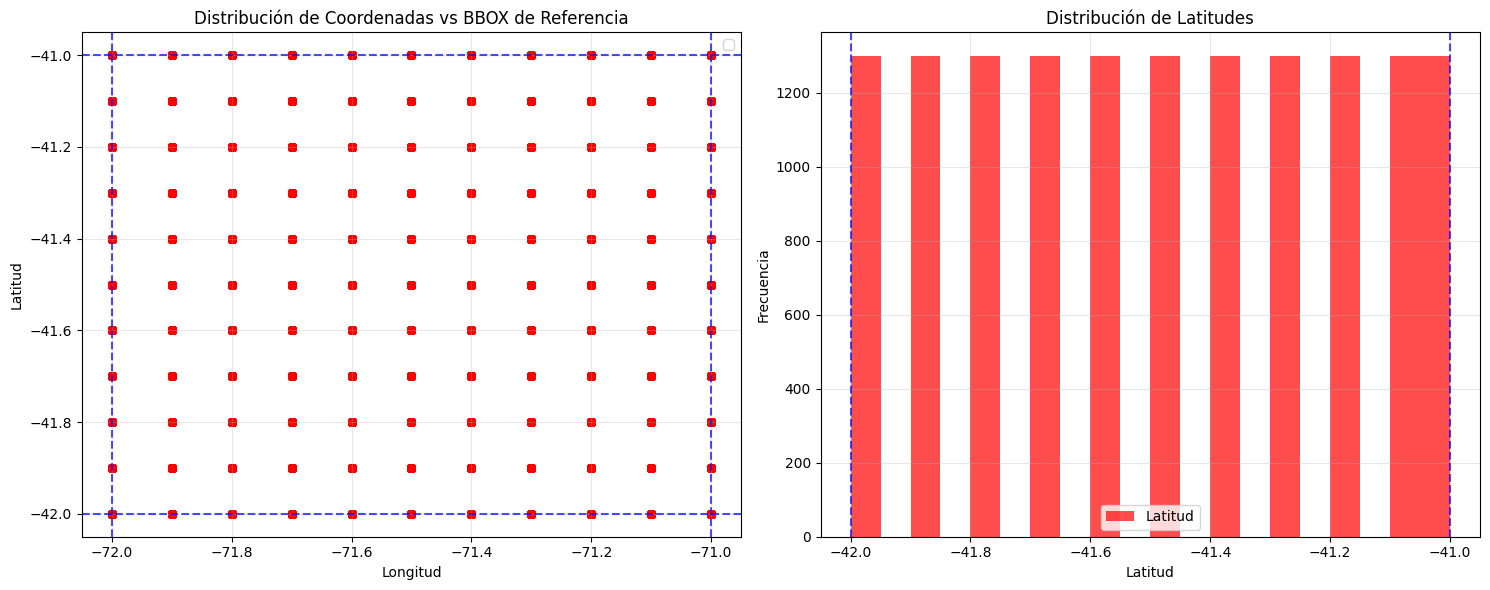

In [6]:
################################################
# INFORME GRÁFICO DE DISTRIBUCIÓN ESPACIAL
################################################

bbox_ref = cfg.BBOX_ERA5
fig, axes = plt.subplots(1, 2, figsize = (15, 6))

# Scatter plot de coordenadas
scatter = axes[0].scatter(df['longitude'], df['latitude'], 
                         alpha = 0.6, s = 30, c = 'red')
axes[0].axhline(y = bbox_ref[1], color = 'blue', linestyle = '--', alpha = 0.7)
axes[0].axhline(y = bbox_ref[3], color = 'blue', linestyle = '--', alpha = 0.7)
axes[0].axvline(x = bbox_ref[0], color = 'blue', linestyle = '--', alpha = 0.7)
axes[0].axvline(x = bbox_ref[2], color = 'blue', linestyle = '--', alpha = 0.7)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].set_title('Distribución de Coordenadas vs BBOX de Referencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramas de distribución
axes[1].hist(df['latitude'], bins = 20, alpha = 0.7, label = 'Latitud', color = 'red')
axes[1].axvline(x = bbox_ref[1], color = 'blue', linestyle = '--', alpha = 0.7)
axes[1].axvline(x = bbox_ref[3], color = 'blue', linestyle = '--', alpha = 0.7)
axes[1].set_xlabel('Latitud')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Latitudes')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

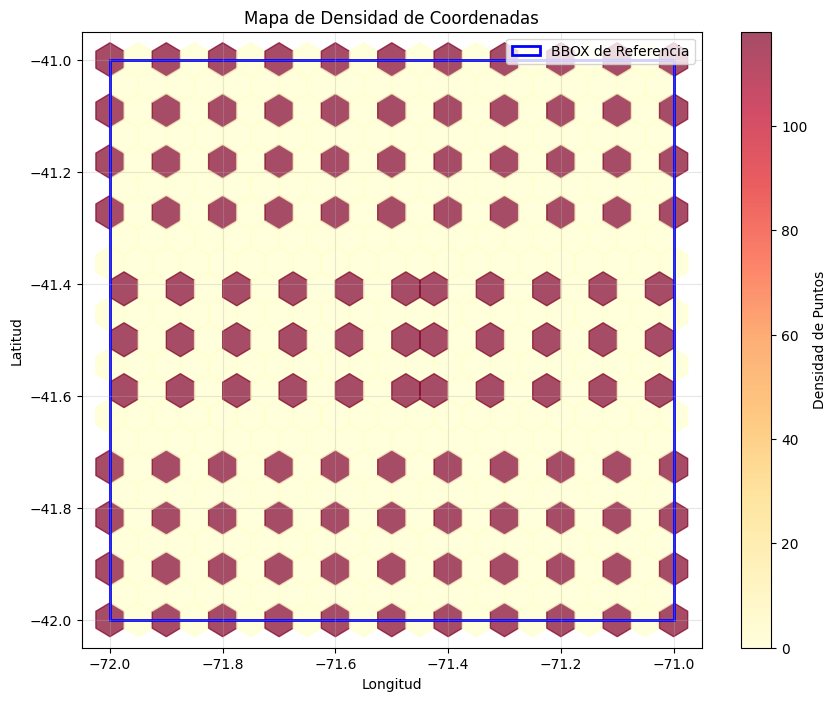

In [7]:
plt.figure(figsize=(10, 8))

# Crear hexbin para densidad
plt.hexbin(df['longitude'], df['latitude'], gridsize=20, cmap='YlOrRd', alpha=0.7)

# Dibujar BBOX de referencia
bbox_rect = plt.Rectangle((-72, -42), 1, 1, fill=False, edgecolor='blue', 
                         linewidth=2, label='BBOX de Referencia')
plt.gca().add_patch(bbox_rect)

plt.colorbar(label='Densidad de Puntos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Mapa de Densidad de Coordenadas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4.2 - Fire Weather Index

In [ ]:
df.head()

In [ ]:
# Evolución temporal del FWI y componentes
fig_temp = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Evolución del FWI', 'Componentes del FWI', 'Condiciones Meteorológicas'),
    vertical_spacing=0.08,
    row_heights=[0.4, 0.3, 0.3]
)

# FWI principal
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['fwi'], 
               name='FWI', line=dict(color='red', width=2)),
    row=1, col=1
)

# Componentes del FWI
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['isi'], name='ISI', line=dict(color='orange')),
    row=2, col=1
)
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['bui'], name='BUI', line=dict(color='brown')),
    row=2, col=1
)
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['ffmc'], name='FFMC', line=dict(color='green')),
    row=2, col=1
)

# Variables meteorológicas clave
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['t2m'], name='Temp (°C)', 
               line=dict(color='red', dash='dot')),
    row=3, col=1
)
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['wind_speed'], name='Viento (m/s)', 
               line=dict(color='blue', dash='dot')),
    row=3, col=1
)
fig_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['precipitacion_mm'], name='Precip (mm)', 
               line=dict(color='cyan', dash='dot'), yaxis='y2'),
    row=3, col=1
)

fig_temp.update_layout(
    height=800,
    title_text="Análisis Temporal del Sistema FWI",
    showlegend=True
)
fig_temp.update_yaxes(title_text="Precipitación (mm)", row=3, col=1, secondary_y=True)
fig_temp.show()

In [ ]:
# Histogramas de componentes FWI
variables_fwi = ['fwi', 'isi', 'bui', 'ffmc', 'dmc', 'dc']
fig_dist = make_subplots(rows=2, cols=3, subplot_titles=variables_fwi)

for i, var in enumerate(variables_fwi):
    row = i // 3 + 1
    col = i % 3 + 1
    fig_dist.add_trace(
        go.Histogram(x=df[var], name=var, nbinsx=30),
        row=row, col=col
    )

fig_dist.update_layout(height=600, title_text="Distribución de Componentes FWI")
fig_dist.show()

In [ ]:
# Matriz de correlación
variables_corr = ['fwi', 'isi', 'bui', 'ffmc', 'dmc', 'dc', 't2m', 'wind_speed', 
                  'precipitacion_mm', 'humedad_relativa']

corr_matrix = df[variables_corr].corr()

fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="Matriz de Correlación - Variables FWI y Meteorológicas"
)
fig_corr.show()

In [ ]:
# Distribución de categorías de riesgo
riesgo_counts = df['riesgo_incendio'].value_counts()

fig_riesgo = px.pie(
    values=riesgo_counts.values,
    names=riesgo_counts.index,
    title="Distribución de Categorías de Riesgo",
    color=riesgo_counts.index,
    color_discrete_map={
        'Muy Bajo': 'green',
        'Bajo': 'lightgreen',
        'Moderado': 'orange',
        'Alto': 'red',
        'Extremo': 'darkred'
    }
)
fig_riesgo.show()

# Estadísticas por categoría de riesgo
stats_por_riesgo = df.groupby('riesgo_incendio').agg({
    'fwi': ['mean', 'max', 'std'],
    't2m': 'mean',
    'wind_speed': 'mean',
    'precipitacion_mm': 'mean',
    'humedad_relativa': 'mean',
    'has_fire': 'sum'
}).round(2)

print("=== ESTADÍSTICAS POR CATEGORÍA DE RIESGO ===")
print(stats_por_riesgo)

In [ ]:
# Comparación días con/sin incendio
fig_incendios = make_subplots(rows=2, cols=2, 
                             subplot_titles=('FWI vs Incendios', 'ISI vs Incendios',
                                           'Temperatura vs Incendios', 'Viento vs Incendios'))

# FWI
fig_incendios.add_trace(
    go.Box(x=df['has_fire'].map({0: 'Sin Fuego', 1: 'Con Fuego'}), 
           y=df['fwi'], name='FWI'),
    row=1, col=1
)

# ISI
fig_incendios.add_trace(
    go.Box(x=df['has_fire'].map({0: 'Sin Fuego', 1: 'Con Fuego'}), 
           y=df['isi'], name='ISI'),
    row=1, col=2
)

# Temperatura
fig_incendios.add_trace(
    go.Box(x=df['has_fire'].map({0: 'Sin Fuego', 1: 'Con Fuego'}), 
           y=df['t2m'], name='Temperatura'),
    row=2, col=1
)

# Viento
fig_incendios.add_trace(
    go.Box(x=df['has_fire'].map({0: 'Sin Fuego', 1: 'Con Fuego'}), 
           y=df['wind_speed'], name='Viento'),
    row=2, col=2
)

fig_incendios.update_layout(height=600, title_text="Comparación Variables en Días con/sin Incendio")
fig_incendios.show()

In [ ]:
# Calcular percentiles para definir umbrales
percentiles = [5, 25, 50, 75, 95, 99]
fwi_percentiles = df['fwi'].quantile([p/100 for p in percentiles])

print("=== UMBRALES DE FWI POR PERCENTILES ===")
for p, val in zip(percentiles, fwi_percentiles):
    print(f"P{p}: {val:.2f}")

# Visualizar distribución con umbrales
fig_umbrales = go.Figure()

fig_umbrales.add_trace(go.Histogram(x=df['fwi'], nbinsx=50, name='Distribución FWI'))

# Añadir líneas de percentiles
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
for i, (p, val) in enumerate(zip(percentiles, fwi_percentiles)):
    fig_umbrales.add_vline(
        x=val, 
        line_dash="dash", 
        line_color=colors[i],
        annotation_text=f'P{p}: {val:.2f}'
    )

fig_umbrales.update_layout(
    title="Distribución de FWI con Umbrales de Percentil",
    xaxis_title="FWI",
    yaxis_title="Frecuencia"
)
fig_umbrales.show()

In [ ]:
# Scatter matrix de variables clave
fig_scatter = px.scatter_matrix(
    df,
    dimensions=['fwi', 't2m', 'wind_speed', 'humedad_relativa', 'precipitacion_mm'],
    color='riesgo_incendio',
    color_discrete_map={
        'Muy Bajo': 'green',
        'Bajo': 'lightgreen', 
        'Moderado': 'orange'
    },
    title="Relaciones Multivariadas - Sistema FWI"
)
fig_scatter.update_traces(diagonal_visible=False)
fig_scatter.show()

In [ ]:
def generar_resumen_fwi(df):
    print("=== RESUMEN SISTEMA FWI ===")
    print(f"📅 Período: {df['acq_datetime'].min()} a {df['acq_datetime'].max()}")
    print(f"📍 Puntos geográficos: {df[['latitude', 'longitude']].drop_duplicates().shape[0]}")
    print(f"🔥 Días con incendios: {df['has_fire'].sum()} ({df['has_fire'].mean()*100:.1f}%)")
    print(f"📊 Rango FWI: {df['fwi'].min():.2f} - {df['fwi'].max():.2f}")
    print(f"🎯 FWI promedio: {df['fwi'].mean():.2f}")
    print(f"⚠️ Máximo FWI registrado: {df['fwi'].max():.2f}")
    
    # Efectividad del sistema
    if df['has_fire'].sum() > 0:
        fwi_incendios = df[df['has_fire'] == 1]['fwi']
        print(f"📈 FWI promedio en días con incendio: {fwi_incendios.mean():.2f}")
        print(f"📉 FWI promedio en días sin incendio: {df[df['has_fire'] == 0]['fwi'].mean():.2f}")

generar_resumen_fwi(df)

In [ ]:
# Preparar datos para el mapa de riesgo
location_risk = df.groupby(['latitude', 'longitude']).agg({
    'riesgo_incendio' : lambda x : x.mode()[0] if len(x.mode()) > 0 else 'Muy Bajo',
    'acq_datetime' : 'count'
}).reset_index()
location_risk.columns = ['lat', 'lon', 'riesgo_predominante', 'num_registros']

# Mapa de riesgo con Plotly
fig_risk = px.scatter_map(
    location_risk,
    lat = 'lat',
    lon = 'lon',
    color = 'riesgo_predominante',
    color_discrete_map = {
        'Muy Bajo': 'green',
        'Bajo': 'lightgreen', 
        'Moderado': 'orange'
    },
    size = 'num_registros',
    size_max = 15,
    hover_data = ['num_registros'],
    zoom = 7,
    height = 600,
    title = 'Mapa de Riesgo de Incendio Predominante'
)

# Añadir BBOX
fig_risk.add_trace(go.Scattermap(
    lat = [-42.0, -42.0, -41.0, -41.0, -42.0],
    lon = [-72.0, -71.0, -71.0, -72.0, -72.0],
    mode = 'lines',
    line = dict(width=3, color='blue'),
    name = 'BBOX',
    hoverinfo = 'text',
    text = 'Área objetivo de estudio'
))

fig_risk.update_layout(
    mapbox_style = "open-street-map",
    margin={"r" : 0, "t" : 40, "l" : 0, "b" : 0},
    legend = dict(
        yanchor = "top",
        y = 0.99,
        xanchor = "left",
        x = 0.01
    )
)

fig_risk.show()


### 4.3 - Focos de calor

In [ ]:
# Análisis detallado de focos de calor
print("=== ANÁLISIS EXHAUSTIVO DE FOCOS DE CALOR ===")
print(f"Total de registros: {len(df)}")
print(f"Registros con focos: {len(df[df['num_focos'] > 0])} ({len(df[df['num_focos'] > 0])/len(df)*100:.1f}%)")
print(f"Registros sin focos: {len(df[df['num_focos'] == 0])} ({len(df[df['num_focos'] == 0])/len(df)*100:.1f}%)")

# Estadísticas detalladas
focos_stats = df['num_focos'].describe()
print(f"\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
print(f"Media: {focos_stats['mean']:.2f}")
print(f"Desviación estándar: {focos_stats['std']:.2f}")
print(f"Máximo: {focos_stats['max']}")
print(f"Percentil 75%: {focos_stats['75%']}")
print(f"Percentil 95%: {df['num_focos'].quantile(0.95)}")

# Distribución de valores
unique_focos = df['num_focos'].value_counts().sort_index()
print(f"\n🎯 DISTRIBUCIÓN DE VALORES:")
for valor, count in unique_focos.head(10).items():
    print(f"  {valor} focos: {count} registros ({count/len(df)*100:.1f}%)")

In [ ]:
# Evolución temporal de focos
fig_focos_temp = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Evolución Temporal de Focos de Calor', 'Acumulado de Focos por Día'),
    vertical_spacing=0.1
)

# Serie temporal
fig_focos_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['num_focos'], 
               mode='markers+lines', name='Focos diarios',
               marker=dict(size=6, color='red', opacity=0.7),
               line=dict(color='red', width=1)),
    row=1, col=1
)

# Acumulado por día
focos_diarios = df.groupby('acq_datetime')['num_focos'].sum().cumsum()
fig_focos_temp.add_trace(
    go.Scatter(x=focos_diarios.index, y=focos_diarios.values,
               mode='lines', name='Acumulado total',
               line=dict(color='darkred', width=3)),
    row=2, col=1
)

fig_focos_temp.update_layout(height=600, title_text="Análisis Temporal de Focos de Calor")
fig_focos_temp.show()

In [ ]:
# Mapa de densidad de focos
focos_por_ubicacion = df.groupby(['latitude', 'longitude']).agg({
    'num_focos': 'sum',
    'has_fire': 'max',
    'acq_datetime': 'count'
}).reset_index()

fig_mapa_focos = px.density_map(
    focos_por_ubicacion,
    lat='latitude',
    lon='longitude',
    z='num_focos',
    radius=20,
    center=dict(lat=-41.5, lon=-71.8),
    zoom=7,
    map_style="open-street-map",
    title="Mapa de Densidad de Focos de Calor",
    height=600
)

# Añadir puntos con focos
focos_positivos_map = focos_por_ubicacion[focos_por_ubicacion['num_focos'] > 0]
fig_mapa_focos.add_trace(
    go.Scattermap(
        lat=focos_positivos_map['latitude'],
        lon=focos_positivos_map['longitude'],
        mode='markers',
        marker=dict(size=8, color='red'),
        text=focos_positivos_map['num_focos'],
        name='Puntos con focos'
    )
)

fig_mapa_focos.show()

In [ ]:
# Comparación de condiciones con y sin focos
variables_comparacion = ['fwi', 't2m', 'wind_speed', 'humedad_relativa', 'precipitacion_mm']

fig_comparacion = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'Focos vs {var.upper()}' for var in variables_comparacion] + ['Distribución Focos'],
    specs=[[{"secondary_y": False}, {"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}, {"secondary_y": False}]]
)

for i, var in enumerate(variables_comparacion):
    row = i // 3 + 1
    col = i % 3 + 1
    
    # Boxplot comparativo
    fig_comparacion.add_trace(
        go.Box(x=df['num_focos'] > 0, 
               y=df[var],
               name=var),
        row=row, col=col
    )

# Distribución de focos
fig_comparacion.add_trace(
    go.Histogram(x=df[df['num_focos'] > 0]['num_focos'], 
                 nbinsx=20, name='Distribución focos'),
    row=2, col=3
)

fig_comparacion.update_layout(
    height=700,
    title_text="Relación entre Focos y Variables Ambientales",
    showlegend=False
)
fig_comparacion.show()

In [ ]:
# Análisis de intensidad de focos
print("=== ANÁLISIS DE INTENSIDAD (FRP) ===")
print(f"FRP promedio: {df['frp_mean'].mean():.2f}")
print(f"FRP máximo: {df['frp_mean'].max():.2f}")
print(f"FRP en días con focos: {df[df['num_focos'] > 0]['frp_mean'].mean():.2f}")

# Relación entre número de focos e intensidad
fig_frp = make_subplots(
    rows=1, cols=2,
    subplot_titles=('FRP vs Número de Focos', 'Distribución de FRP')
)

# Scatter plot
fig_frp.add_trace(
    go.Scatter(x=df['num_focos'], y=df['frp_mean'],
               mode='markers', name='FRP vs Focos',
               marker=dict(color=df['fwi'], colorscale='Viridis', 
                          colorbar=dict(title="FWI"))),
    row=1, col=1
)

# Distribución de FRP
fig_frp.add_trace(
    go.Histogram(x=df[df['frp_mean'] > 0]['frp_mean'], 
                 nbinsx=30, name='Distribución FRP'),
    row=1, col=2
)

fig_frp.update_layout(height=400, title_text="Análisis de Intensidad de Focos (FRP)")
fig_frp.show()

In [ ]:
# Identificar umbrales críticos
def analizar_umbrales_focos(df):
    print("=== ANÁLISIS DE UMBRALES PARA FOCOS ===")
    
    # Umbrales de FWI para diferentes números de focos
    for num_focos in sorted(df['num_focos'].unique()):
        if num_focos > 0:
            subset = df[df['num_focos'] == num_focos]
            print(f"\n🔍 {num_focos} foco(s):")
            print(f"   Muestra: {len(subset)} registros")
            print(f"   FWI promedio: {subset['fwi'].mean():.2f}")
            print(f"   Temp promedio: {subset['t2m'].mean():.2f}°C")
            print(f"   Viento promedio: {subset['wind_speed'].mean():.2f} m/s")
            print(f"   FRP promedio: {subset['frp_mean'].mean():.2f}")

analizar_umbrales_focos(df)

In [ ]:
# Correlación focos con otras variables
variables_corr_focos = ['num_focos', 'fwi', 'isi', 'bui', 't2m', 'wind_speed', 
                        'precipitacion_mm', 'humedad_relativa', 'frp_mean']

corr_focos = df[variables_corr_focos].corr()

fig_corr_focos = px.imshow(
    corr_focos,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="Correlación: Focos vs Variables Ambientales"
)
fig_corr_focos.show()

# Correlación específica con num_focos
print("\n📈 CORRELACIONES CON NÚMERO DE FOCOS:")
correlaciones = corr_focos['num_focos'].sort_values(ascending=False)
for var, corr in correlaciones.items():
    if var != 'num_focos':
        print(f"   {var}: {corr:.3f}")

In [ ]:
# Identificar días con mayor actividad de focos
dias_con_mas_focos = df.nlargest(10, 'num_focos')[['acq_datetime', 'num_focos', 'fwi', 't2m', 'wind_speed', 'frp_mean']]

print("=== DÍAS CON MAYOR ACTIVIDAD DE FOCOS ===")
print(dias_con_mas_focos.round(2))

# Análisis de clusters temporales
df['fecha'] = pd.to_datetime(df['acq_datetime'])
df['semana'] = df['fecha'].dt.isocalendar().week

focos_semanales = df.groupby('semana').agg({
    'num_focos': 'sum',
    'has_fire': 'sum'
}).reset_index()

fig_semanas = px.bar(
    focos_semanales, 
    x='semana', 
    y='num_focos',
    title="Focos de Calor por Semana",
    labels={'num_focos': 'Total Focos', 'semana': 'Semana del Año'}
)
fig_semanas.show()

In [ ]:
def resumen_ejecutivo_focos(df):
    focos_positivos = df[df['num_focos'] > 0]
    
    print("=== RESUMEN EJECUTIVO - FOCOS DE CALOR ===")
    print(f"🔥 TOTAL FOCOS REGISTRADOS: {df['num_focos'].sum()}")
    print(f"📅 DÍAS CON FOCOS: {len(focos_positivos)}")
    print(f"📍 PUNTOS GEOGRÁFICOS CON FOCOS: {focos_positivos[['latitude', 'longitude']].drop_duplicates().shape[0]}")
    print(f"📈 MÁXIMO FOCOS EN UN DÍA: {df['num_focos'].max()}")
    print(f"🎯 FRP PROMEDIO: {df[df['frp_mean'] > 0]['frp_mean'].mean():.2f}")
    
    if len(focos_positivos) > 0:
        print(f"\n⚠️  CONDICIONES PROMEDIO EN DÍAS CON FOCOS:")
        print(f"   • FWI: {focos_positivos['fwi'].mean():.2f}")
        print(f"   • Temperatura: {focos_positivos['t2m'].mean():.2f}°C")
        print(f"   • Viento: {focos_positivos['wind_speed'].mean():.2f} m/s")
        print(f"   • Humedad: {focos_positivos['humedad_relativa'].mean():.2f}%")

resumen_ejecutivo_focos(df)

In [ ]:
fig_combined = go.Figure()
if df['num_focos'].sum() > 0:
    location_focos = df.groupby(['latitude', 'longitude']).agg({
        'num_focos': 'sum',
        'acq_datetime': 'count',
        'fwi': 'mean',
        'riesgo_incendio': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Muy Bajo'
    }).reset_index()
    
    fig_combined.add_trace(go.Scattermap(
        lat = location_focos['latitude'],
        lon = location_focos['longitude'],
        mode = 'markers',
        marker = dict(
            size = location_focos['num_focos'] / 10,
            color = location_focos['num_focos'],
            colorscale = 'reds',
            showscale = True,
            colorbar = dict(title = "Total Focos")
        ),
        name = 'Focos de Incendio',
        text=[f'Ubicación: ({lat:.4f}, {lon:.4f})<br>Total focos: {focos}<br>Días con datos: {dias}<br>FWI promedio: {fwi:.2f}<br>Riesgo: {riesgo}'
              for lat, lon, focos, dias, fwi, riesgo in zip(
                  location_focos['latitude'], 
                  location_focos['longitude'],
                  location_focos['num_focos'],
                  location_focos['acq_datetime'],
                  location_focos['fwi'],
                  location_focos['riesgo_incendio']
              )],
        hoverinfo='text'
    ))
else:
    location_fwi = df.groupby(['latitude', 'longitude']).agg({
        'fwi': 'mean',
        'riesgo_incendio': lambda x: x.mode()[0]
    }).reset_index()
    
    fig_combined.add_trace(go.Scattermap(
        lat = location_fwi['latitude'],
        lon = location_fwi['longitude'],
        mode = 'markers',
        marker = dict(
            size = 15,
            color = location_fwi['fwi'],
            colorscale = 'reds',
            showscale = True,
            colorbar = dict(title="FWI Promedio")
        ),
        name = 'Índice FWI Promedio',
        text = [f'Ubicación: ({lat:.4f}, {lon:.4f})<br>FWI promedio: {fwi:.2f}<br>Riesgo: {riesgo}'
                for lat, lon, fwi, riesgo in zip(
                  location_fwi['latitude'], 
                  location_fwi['longitude'],
                  location_fwi['fwi'],
                  location_fwi['riesgo_incendio']
              )],
        hoverinfo = 'text'
    ))
fig_combined.add_trace(go.Scattermap(
    lat = [-42.0, -42.0, -41.0, -41.0, -42.0],
    lon = [-72.0, -71.0, -71.0, -72.0, -72.0],
    mode = 'lines',
    line = dict(width = 3, color = 'blue'),
    name = 'BBOX de Referencia'
))
fig_combined.update_layout(
    mapbox = dict(
        style = "open-street-map",
        center = dict(lat=df['latitude'].mean(), lon=df['longitude'].mean()),
        zoom = 7
    ),
    title = 'Distribución Espacial de Focos de Incendio e Índice de Riesgo',
    height = 600,
    margin = {"r":0,"t":40,"l":0,"b":0}
)
fig_combined.show()

In [ ]:
# Análisis temporal de focos.
if df['num_focos'].sum() > 0:
    focos_temporal = df.groupby('acq_datetime').agg({
        'num_focos': 'sum',
        'latitude': 'count'
    }).reset_index()
    
    fig_temporal = px.line(
        focos_temporal,
        x = 'acq_datetime',
        y = 'num_focos',
        title = 'Evolución Temporal del Número de Focos de Incendio',
        labels = {'num_focos': 'Número de Focos', 'acq_datetime': 'Fecha'}
    )
    
    fig_temporal.update_layout(
        xaxis = dict(tickformat='%d/%m/%Y'),
        height = 400
    )
    
    fig_temporal.show()

    primer_foco = focos_temporal[focos_temporal['num_focos'] > 0]['acq_datetime'].min()
    ultimo_foco = focos_temporal[focos_temporal['num_focos'] > 0]['acq_datetime'].max()

    print(f"📅 Período con focos: {primer_foco} a {ultimo_foco}")
    print(f"🔥 Días con focos: {len(focos_temporal[focos_temporal['num_focos'] > 0])}")
    print(f"📊 Máximo diario de focos: {focos_temporal['num_focos'].max()}")

In [ ]:
# Primero identifiquemos las coordenadas que tienen focos
if df['num_focos'].sum() > 0:

    # Identificar coordenadas con focos positivos
    coordenadas_con_focos = df[df['num_focos'] > 0][['latitude', 'longitude']].drop_duplicates()
    
    print(f"📍 Coordenadas únicas con focos: {len(coordenadas_con_focos)}")
    
    # Crear gráficos individuales para cada coordenada
    for idx, (lat, lon) in enumerate(coordenadas_con_focos.values):
        # Filtrar datos para esta coordenada específica
        datos_coordenada = df[
            (df['latitude'] == lat) & 
            (df['longitude'] == lon)
        ].sort_values('acq_datetime')
        
        # Crear gráfico individual
        fig_individual = px.line(
            datos_coordenada,
            x='acq_datetime',
            y='num_focos',
            title=f'Evolución Temporal de Focos - Coordenadas ({lat:.4f}, {lon:.4f})',
            labels={'num_focos': 'Número de Focos', 'acq_datetime': 'Fecha'},
            markers=True
        )
        
        # Personalizar el gráfico
        fig_individual.update_layout(
            xaxis=dict(
                tickformat='%d/%m/%Y',
                tickangle=45
            ),
            height=400,
            showlegend=False
        )
        
        # Añadir línea en y=0 para mejor visualización
        fig_individual.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
        
        # Mostrar estadísticas en el gráfico
        max_focos = datos_coordenada['num_focos'].max()
        total_focos = datos_coordenada['num_focos'].sum()
        dias_con_focos = len(datos_coordenada[datos_coordenada['num_focos'] > 0])
        
        fig_individual.add_annotation(
            x=0.02, y=0.98,
            xref="paper", yref="paper",
            text=f"Total focos: {total_focos}<br>Máximo diario: {max_focos}<br>Días con focos: {dias_con_focos}",
            showarrow=False,
            bgcolor="white",
            bordercolor="black",
            borderwidth=1
        )
        
        fig_individual.show()
        
        # Imprimir resumen por consola
        print(f"\n{'='*60}")
        print(f"📍 COORDENADA {idx+1}: ({lat:.4f}, {lon:.4f})")
        print(f"{'='*60}")
        print(f"📊 Total de focos: {total_focos}")
        print(f"🔥 Máximo diario: {max_focos}")
        print(f"📅 Días con focos: {dias_con_focos}")
        print(f"🕐 Período: {datos_coordenada['acq_datetime'].min()} a {datos_coordenada['acq_datetime'].max()}")
else:
    print("No hay focos positivos en el dataset")


### 4.4 - Meteorología

In [ ]:
# Definir variables meteorológicas clave
meteo_vars = {
    't2m': 'Temperatura a 2m (°C)',
    'd2m': 'Temperatura de rocío a 2m (°C)',
    'humedad_relativa': 'Humedad Relativa (%)',
    'wind_speed': 'Velocidad del Viento (m/s)',
    'precipitacion_mm': 'Precipitación (mm)',
    'ssr': 'Radiación Solar (J/m²)',
    'str': 'Radiación Térmica (J/m²)',
    'e': 'Evaporación (m)',
    'tp': 'Precipitación Total (m)',
    'sp': 'Presión Superficial (Pa)'
}

print("=== RESUMEN ESTADÍSTICO VARIABLES METEOROLÓGICAS ===")
for var, desc in meteo_vars.items():
    if var in df.columns:
        stats = df[var].describe()
        print(f"\n📊 {desc} ({var}):")
        print(f"   Media: {stats['mean']:.2f}")
        print(f"   Min: {stats['min']:.2f}")
        print(f"   Max: {stats['max']:.2f}")
        print(f"   Std: {stats['std']:.2f}")

In [ ]:
# Series temporales de variables meteorológicas
fig_meteo_temp = make_subplots(
    rows=4, cols=1,
    subplot_titles=('Temperatura y Humedad', 'Viento', 'Precipitación', 'Radiación'),
    vertical_spacing=0.08,
    row_heights=[0.25, 0.25, 0.25, 0.25]
)

# Temperatura y humedad
fig_meteo_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['t2m'], name='Temp (°C)', 
               line=dict(color='red')),
    row=1, col=1
)
fig_meteo_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['humedad_relativa'], name='Humedad (%)',
               line=dict(color='blue'), yaxis='y2'),
    row=1, col=1
)

# Viento
fig_meteo_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['wind_speed'], name='Viento (m/s)',
               line=dict(color='green')),
    row=2, col=1
)

# Precipitación
fig_meteo_temp.add_trace(
    go.Bar(x=df['acq_datetime'], y=df['precipitacion_mm'], name='Precip (mm)',
           marker_color='lightblue'),
    row=3, col=1
)

# Radiación
fig_meteo_temp.add_trace(
    go.Scatter(x=df['acq_datetime'], y=df['ssr']/1e6, name='Rad Solar (MJ/m²)',
               line=dict(color='orange')),
    row=4, col=1
)

fig_meteo_temp.update_layout(
    height=800,
    title_text="Evolución Temporal de Variables Meteorológicas",
    showlegend=True
)
fig_meteo_temp.update_yaxes(title_text="Humedad (%)", row=1, col=1, secondary_y=True)
fig_meteo_temp.show()

In [ ]:
# Matriz de correlación específica para meteorología
vars_corr_meteo = ['t2m', 'd2m', 'humedad_relativa', 'wind_speed', 'precipitacion_mm', 
                   'ssr', 'str', 'e', 'sp', 'fwi', 'num_focos']

corr_meteo = df[vars_corr_meteo].corr()

fig_corr_meteo = px.imshow(
    corr_meteo,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="Correlación: Variables Meteorológicas vs FWI y Focos"
)
fig_corr_meteo.show()

# Correlaciones más importantes con FWI
print("=== CORRELACIONES CON FWI ===")
corr_fwi = corr_meteo['fwi'].sort_values(ascending=False)
for var, corr_val in corr_fwi.items():
    if var != 'fwi' and abs(corr_val) > 0.3:
        print(f"   {var}: {corr_val:.3f}")

In [ ]:
# Identificar días con condiciones meteorológicas extremas
def analizar_extremos_meteo(df):
    print("=== CONDICIONES METEOROLÓGICAS EXTREMAS ===")
    
    # Días más calurosos
    dias_calidos = df.nlargest(5, 't2m')[['acq_datetime', 't2m', 'humedad_relativa', 'fwi', 'num_focos']]
    print("\n🔥 DÍAS MÁS CÁLIDOS:")
    print(dias_calidos.round(2))
    
    # Días más secos (baja humedad)
    dias_secos = df.nsmallest(5, 'humedad_relativa')[['acq_datetime', 'humedad_relativa', 't2m', 'fwi', 'num_focos']]
    print("\n🏜️  DÍAS MÁS SECOS:")
    print(dias_secos.round(2))
    
    # Días más ventosos
    dias_ventosos = df.nlargest(5, 'wind_speed')[['acq_datetime', 'wind_speed', 't2m', 'fwi', 'num_focos']]
    print("\n💨 DÍAS MÁS VENTOSOS:")
    print(dias_ventosos.round(2))
    
    # Días con más precipitación
    dias_lluviosos = df.nlargest(5, 'precipitacion_mm')[['acq_datetime', 'precipitacion_mm', 'humedad_relativa', 'fwi', 'num_focos']]
    print("\n🌧️  DÍAS MÁS LLUVIOSOS:")
    print(dias_lluviosos.round(2))

analizar_extremos_meteo(df)

In [ ]:
# Scatter plots de interacciones clave
fig_interacciones = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Temperatura vs Humedad', 
        'Viento vs Temperatura',
        'Precipitación vs Humedad',
        'Radiación vs Temperatura'
    )
)

# Temperatura vs Humedad
fig_interacciones.add_trace(
    go.Scatter(x=df['t2m'], y=df['humedad_relativa'], 
               mode='markers', name='Temp-Humedad',
               marker=dict(color=df['fwi'], colorscale='Viridis', 
                          size=8, showscale=True,
                          colorbar=dict(title="FWI"))),
    row=1, col=1
)

# Viento vs Temperatura
fig_interacciones.add_trace(
    go.Scatter(x=df['wind_speed'], y=df['t2m'],
               mode='markers', name='Viento-Temp',
               marker=dict(color=df['num_focos'], colorscale='Reds',
                          size=8, showscale=True,
                          colorbar=dict(title="Focos"))),
    row=1, col=2
)

# Precipitación vs Humedad
fig_interacciones.add_trace(
    go.Scatter(x=df['precipitacion_mm'], y=df['humedad_relativa'],
               mode='markers', name='Precip-Humedad',
               marker=dict(color=df['t2m'], colorscale='Plasma',
                          size=8, showscale=True,
                          colorbar=dict(title="Temp (°C)"))),
    row=2, col=1
)

# Radiación vs Temperatura
fig_interacciones.add_trace(
    go.Scatter(x=df['ssr']/1e6, y=df['t2m'],
               mode='markers', name='Rad-Temp',
               marker=dict(color=df['wind_speed'], colorscale='Blues',
                          size=8, showscale=True,
                          colorbar=dict(title="Viento (m/s)"))),
    row=2, col=2
)

fig_interacciones.update_layout(height=700, title_text="Interacciones entre Variables Meteorológicas")
fig_interacciones.show()

In [ ]:
# Calcular variables derivadas interesantes
df['déficit_saturación'] = df['t2m'] - df['d2m']  # Diferencia temperatura-rocio
df['presión_normalizada'] = (df['sp'] - df['sp'].mean()) / df['sp'].std()

print("=== VARIABLES DERIVADAS ===")
print(f"Déficit de saturación promedio: {df['déficit_saturación'].mean():.2f}°C")
print(f"Presión normalizada std: {df['presión_normalizada'].std():.2f}")

# Análisis de déficit de saturación vs FWI
fig_deficit = px.scatter(
    df, x='déficit_saturación', y='fwi',
    color='num_focos', size='wind_speed',
    title="Déficit de Saturación vs FWI",
    labels={'déficit_saturación': 'Déficit de Saturación (°C)', 'fwi': 'FWI'}
)
fig_deficit.show()

In [ ]:
# Crear categorías para análisis
df['temp_categoria'] = pd.cut(df['t2m'], 
                             bins=[-10, 0, 10, 20, 30, 40],
                             labels=['<0°C', '0-10°C', '10-20°C', '20-30°C', '>30°C'])

df['humedad_categoria'] = pd.cut(df['humedad_relativa'],
                                bins=[0, 30, 50, 70, 100],
                                labels=['<30%', '30-50%', '50-70%', '>70%'])

# Estadísticas por categorías
print("=== ESTADÍSTICAS POR CATEGORÍAS DE TEMPERATURA ===")
stats_temp = df.groupby('temp_categoria').agg({
    'fwi': 'mean',
    'num_focos': ['sum', 'count'],
    'wind_speed': 'mean',
    'humedad_relativa': 'mean'
}).round(2)
print(stats_temp)

print("\n=== ESTADÍSTICAS POR CATEGORÍAS DE HUMEDAD ===")
stats_humedad = df.groupby('humedad_categoria').agg({
    'fwi': 'mean',
    'num_focos': ['sum', 'count'],
    't2m': 'mean',
    'precipitacion_mm': 'mean'
}).round(2)
print(stats_humedad)

In [ ]:
# Análisis de componentes u10 y v10
if 'u10' in df.columns and 'v10' in df.columns:
    print("=== ANÁLISIS DE COMPONENTES DEL VIENTO ===")
    
    # Dirección predominante del viento
    df['wind_direction_deg'] = np.degrees(np.arctan2(df['v10'], df['u10'])) % 360
    
    fig_viento = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Rosa de Vientos', 'Componentes U10 vs V10'),
        specs=[[{'type': 'polar'}, {'type': 'xy'}]]
    )
    
    # Rosa de vientos
    fig_viento.add_trace(
        go.Scatterpolar(r=df['wind_speed'], theta=df['wind_direction_deg'],
                       mode='markers', name='Dirección viento',
                       marker=dict(size=6, color=df['t2m'], 
                                  colorscale='Viridis', showscale=True)),
        row=1, col=1
    )
    
    # Componentes
    fig_viento.add_trace(
        go.Scatter(x=df['u10'], y=df['v10'],
                   mode='markers', name='Componentes',
                   marker=dict(size=6, color=df['fwi'], 
                              colorscale='Reds', showscale=True)),
        row=1, col=2
    )
    
    fig_viento.update_layout(height=500, title_text="Análisis de Componentes del Viento")
    fig_viento.show()

In [ ]:
# Análisis de variables de radiación y flujos de calor
vars_energia = ['ssr', 'str', 'slhf', 'sshf', 'ssrd', 'strd']

if all(var in df.columns for var in vars_energia):
    print("=== ANÁLISIS DE FLUJOS DE ENERGÍA ===")
    
    # Normalizar valores grandes
    df_energia = df[vars_energia].copy()
    df_energia = df_energia / 1e6  # Convertir a MJ/m²
    
    fig_energia = px.scatter_matrix(
        df_energia,
        title="Relaciones entre Flujos de Energía (MJ/m²)",
        labels={col: f"{col} (MJ/m²)" for col in df_energia.columns}
    )
    fig_energia.update_traces(diagonal_visible=False)
    fig_energia.show()

In [ ]:
def resumen_meteorologico(df):
    print("=== RESUMEN EJECUTIVO METEOROLÓGICO ===")
    print(f"🌡️  TEMPERATURA: {df['t2m'].mean():.1f}°C (rango: {df['t2m'].min():.1f} a {df['t2m'].max():.1f}°C)")
    print(f"💧 HUMEDAD: {df['humedad_relativa'].mean():.1f}% (rango: {df['humedad_relativa'].min():.1f} a {df['humedad_relativa'].max():.1f}%)")
    print(f"💨 VIENTO: {df['wind_speed'].mean():.1f} m/s (máx: {df['wind_speed'].max():.1f} m/s)")
    print(f"🌧️  PRECIPITACIÓN: {df['precipitacion_mm'].sum():.1f} mm total")
    print(f"📈 CORRELACIÓN TEMP-FWI: {df['t2m'].corr(df['fwi']):.3f}")
    print(f"📉 CORRELACIÓN HUMEDAD-FWI: {df['humedad_relativa'].corr(df['fwi']):.3f}")
    
    # Condiciones críticas identificadas
    temp_umbral = 25  # °C
    humedad_umbral = 40  # %
    viento_umbral = 5  # m/s
    
    condiciones_criticas = df[
        (df['t2m'] > temp_umbral) & 
        (df['humedad_relativa'] < humedad_umbral) & 
        (df['wind_speed'] > viento_umbral)
    ]
    
    print(f"⚠️  DÍAS CON CONDICIONES CRÍTICAS (T>{temp_umbral}°C, H<{humedad_umbral}%, V>{viento_umbral}m/s): {len(condiciones_criticas)}")
    if len(condiciones_criticas) > 0:
        print(f"   • FWI promedio en días críticos: {condiciones_criticas['fwi'].mean():.2f}")
        print(f"   • Focos en días críticos: {condiciones_criticas['num_focos'].sum()}")

resumen_meteorologico(df)


## 5 - Modelado

In [87]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_val_score, cross_validate
from sklearn.pipeline import make_pipeline

from xgboost import XGBClassifier

In [88]:
df = pd.read_csv(f"{cfg.DATA_PROCESSED}/df_final_20251011_203237.csv")

# Eliminar columnas innecesarias...
df = df.drop(columns=['level_2'])
df['acq_datetime'] = pd.to_datetime(df['acq_datetime'])
df['riesgo_incendio'] = df['riesgo_incendio'].astype('category')
df = df.sort_values(['acq_datetime']).reset_index(drop = True)

In [89]:
coordenadas_entrenamiento = [
    (-41.3, -71.8),
    (-41.3, -71.7),
    (-41.4, -71.8),
    (-41.4, -71.7),
    (-41.5, -71.7),
    (-41.5, -71.8)
]

df_ml = pd.concat([
    df[(df['latitude'] == lat) & (df['longitude'] == lon)]
    for lat, lon in coordenadas_entrenamiento
])

df_ml.shape
df_ml['has_fire'].value_counts()

has_fire
0    511
1    197
Name: count, dtype: int64

In [67]:
df_ml.dtypes

latitude             float64
longitude            float64
acq_datetime          object
date                  object
year                   int64
month                  int64
day                    int64
d2m                  float64
t2m                  float64
fal                  float64
slhf                 float64
ssr                  float64
str                  float64
sshf                 float64
ssrd                 float64
strd                 float64
e                    float64
u10                  float64
v10                  float64
sp                   float64
tp                   float64
lai_hv               float64
lai_lv               float64
humedad_relativa     float64
wind_speed           float64
wind_direction       float64
precipitacion_mm     float64
ffmc                 float64
dmc                  float64
dc                   float64
isi                  float64
bui                  float64
fwi                  float64
riesgo_incendio     category
num_focos     

In [90]:
features = ['d2m', 't2m', 'fal', 'slhf', 'ssr', 'str', 'sshf', 'ssrd', 'strd', 
           'e', 'u10', 'v10', 'sp', 'tp', 'lai_hv', 'lai_lv', 'humedad_relativa', 
           'wind_speed', 'wind_direction', 'precipitacion_mm', 'ffmc', 'dmc', 
           'dc', 'isi', 'bui', 'fwi']

X = df_ml[features]
y = df_ml['has_fire']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, shuffle = False)

In [91]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(n_estimators = 100, random_state = 42, eval_metric = 'logloss')
xgb_model.fit(X_train, y_train)

# SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(probability = True, random_state = 42)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [92]:
def evaluate_model(model, X_test, y_test, model_name, scaled = False):
    if scaled:
        X_test_eval = X_test_scaled
    else:
        X_test_eval = X_test
        
    y_pred = model.predict(X_test_eval)
    y_pred_proba = model.predict_proba(X_test_eval)[:, 1]
    
    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred_proba

def CrossValidationROC_AUC(model, X, y, model_name, scaled = False):
    if scaled:
        scaler_cv = StandardScaler()
        X_scaled = scaler_cv.fit_transform(X)
        X_eval = X_scaled
    else:
        X_eval = X

    groups = df.loc[X.index, 'acq_datetime'].dt.to_period('M')
    cv = StratifiedGroupKFold(n_splits = 5, shuffle = True, random_state = 42)
    scores = cross_val_score(model, X_eval, y, cv = cv, scoring = 'roc_auc', groups=groups, n_jobs=-1)
    
    print(f"\n=== {model_name} - Validación Cruzada ROC-AUC ===")
    print(f"ROC-AUC promedio (5 folds): {scores.mean():.4f} ± {scores.std():.4f}")

rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_probs = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
svm_probs = evaluate_model(svm_model, X_test, y_test, "SVM", scaled = True)

feature_importance = pd.DataFrame({
    'feature': features,
    'Random Forest': rf_model.feature_importances_ * 100,
    'XGBoost': xgb_model.feature_importances_ * 100
}).sort_values('XGBoost', ascending = False)

svm_pipeline = make_pipeline(StandardScaler(), SVC(probability = True, random_state = 42))

print("\n=== IMPORTANCIA DE CARACTERÍSTICAS ===")
print(feature_importance.head(10))
print("\n=== ANÁLISIS DE VALIDACIÓN CRUZADA ===")
CrossValidationROC_AUC(rf_model, X, y, "Random Forest")
CrossValidationROC_AUC(xgb_model, X, y, "XGBoost")
CrossValidationROC_AUC(svm_pipeline, X, y, "SVM", scaled = True)


=== Random Forest ===
Accuracy: 0.8685
ROC-AUC: 0.9412

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       112
           1       0.88      0.83      0.86       101

    accuracy                           0.87       213
   macro avg       0.87      0.87      0.87       213
weighted avg       0.87      0.87      0.87       213


=== XGBoost ===
Accuracy: 0.8357
ROC-AUC: 0.8997

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       112
           1       0.83      0.82      0.83       101

    accuracy                           0.84       213
   macro avg       0.84      0.83      0.84       213
weighted avg       0.84      0.84      0.84       213


=== SVM ===
Accuracy: 0.7793
ROC-AUC: 0.8579

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       112
           1 

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def plot_coordinate_matrix(df, model, features, value_type='probability', 
                         title="Matriz de Coordenadas", figsize=(12, 8)):
    """
    Crea una matriz de coordenadas con visualización de resultados del modelo
    
    Parameters:
    - df: DataFrame con datos
    - model: Modelo entrenado
    - features: Lista de características
    - value_type: 'probability', 'prediction', o 'actual'
    - title: Título del gráfico
    """
    
    # Obtener coordenadas únicas y ordenarlas
    unique_lats = sorted(df['latitude'].unique())
    unique_lons = sorted(df['longitude'].unique())
    
    # Crear matriz para almacenar resultados
    result_matrix = np.full((len(unique_lats), len(unique_lons)), np.nan)
    
    # Colores para el mapa de calor (rojo para incendio, verde para no incendio)
    fire_cmap = LinearSegmentedColormap.from_list('fire_risk', ['green', 'yellow', 'red'])
    
    # Llenar la matriz con valores
    for i, lat in enumerate(unique_lats):
        for j, lon in enumerate(unique_lons):
            # Filtrar datos para esta coordenada
            coord_data = df[(df['latitude'] == lat) & (df['longitude'] == lon)]
            
            if len(coord_data) > 0:
                # Tomar el último registro (más reciente) o promedio
                latest_data = coord_data.iloc[-1:][features]
                
                if value_type == 'probability':
                    # Probabilidad de incendio
                    prob = model.predict_proba(latest_data)[0, 1]
                    result_matrix[i, j] = prob
                    
                elif value_type == 'prediction':
                    # Predicción binaria
                    pred = model.predict(latest_data)[0]
                    result_matrix[i, j] = pred
                    
                elif value_type == 'actual':
                    # Valor real
                    result_matrix[i, j] = coord_data['has_fire'].iloc[-1]
    
    # Crear el heatmap
    plt.figure(figsize=figsize)
    
    if value_type == 'probability':
        vmin, vmax = 0, 1
        fmt = '.2f'
        cmap = fire_cmap
        label = 'Probabilidad de Incendio'
    else:
        vmin, vmax = 0, 1
        fmt = 'd'
        cmap = ['green', 'red']
        label = 'Incendio (1) / No Incendio (0)'
    
    sns.heatmap(result_matrix, 
                xticklabels=[f'{lon:.1f}' for lon in unique_lons],
                yticklabels=[f'{lat:.1f}' for lat in unique_lats],
                annot=True, fmt=fmt, cmap=cmap, 
                cbar_kws={'label': label},
                vmin=vmin, vmax=vmax)
    
    plt.title(f'{title}\n({value_type})', fontsize=14, fontweight='bold')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.tight_layout()
    plt.show()
    
    return result_matrix

def plot_comparison_matrices(df, model, features, date_filter=None):
    """
    Crea una comparación lado a lado: Actual vs Predicciones
    """
    if date_filter:
        df_filtered = df[df['acq_datetime'] >= date_filter]
    else:
        df_filtered = df
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Matriz 1: Valores reales
    plot_single_matrix(df_filtered, ax1, 'actual', 'Valores Reales')
    
    # Matriz 2: Predicciones
    plot_single_matrix(df_filtered, ax2, 'prediction', 'Predicciones', model, features)
    
    # Matriz 3: Probabilidades
    plot_single_matrix(df_filtered, ax3, 'probability', 'Probabilidades', model, features)
    
    plt.tight_layout()
    plt.show()

def plot_single_matrix(df, ax, value_type, title, model=None, features=None):
    """Función auxiliar para plot individual"""
    unique_lats = sorted(df['latitude'].unique())
    unique_lons = sorted(df['longitude'].unique())
    
    result_matrix = np.full((len(unique_lats), len(unique_lons)), np.nan)
    
    for i, lat in enumerate(unique_lats):
        for j, lon in enumerate(unique_lons):
            coord_data = df[(df['latitude'] == lat) & (df['longitude'] == lon)]
            
            if len(coord_data) > 0:
                latest_data = coord_data.iloc[-1]
                
                if value_type == 'actual':
                    result_matrix[i, j] = latest_data['has_fire']
                    
                elif value_type == 'prediction' and model is not None:
                    pred_data = latest_data[features].values.reshape(1, -1)
                    result_matrix[i, j] = model.predict(pred_data)[0]
                    
                elif value_type == 'probability' and model is not None:
                    pred_data = latest_data[features].values.reshape(1, -1)
                    result_matrix[i, j] = model.predict_proba(pred_data)[0, 1]
    
    if value_type == 'probability':
        cmap = 'RdYlGn_r'
        vmin, vmax = 0, 1
        fmt = '.2f'
    else:
        cmap = ['green', 'red']
        vmin, vmax = 0, 1
        fmt = 'd'
    
    sns.heatmap(result_matrix, 
                xticklabels=[f'{lon:.1f}' for lon in unique_lons],
                yticklabels=[f'{lat:.1f}' for lat in unique_lats],
                annot=True, fmt=fmt, cmap=cmap, ax=ax,
                cbar_kws={'label': title},
                vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')

In [104]:
def plot_confusion_matrix(model, X_test_data, y_true_labels, model_name, scaled=False):
    """
    Genera y guarda una matriz de confusión visualizada para un modelo.
    
    Parámetros:
    - model: El modelo entrenado (ej. rf_model).
    - X_test_data: Los datos de prueba (X_test o X_test_scaled).
    - y_true_labels: Las etiquetas verdaderas (y_test).
    - model_name: String con el nombre del modelo para el título.
    - scaled: Bool, indica si se deben usar X_test_scaled (solo para SVM).
    """
    
    # Manejar el escalado para SVM
    if scaled:
        X_test_eval = X_test_scaled
    else:
        X_test_eval = X_test
        
    # 1. Obtener las predicciones
    y_pred = model.predict(X_test_eval)
    
    # 2. Calcular la Matriz de Confusión
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(y_true_labels, y_pred)
    
    # Etiquetas para los ejes
    labels = ['No Fuego (0)', 'Fuego (1)']
    
    # 3. Crear la visualización (heatmap)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,         # Mostrar los números en cada celda
        fmt='d',            # Formato de los números (enteros)
        cmap='Blues',       # Paleta de colores
        xticklabels=labels, 
        yticklabels=labels
    )
    
    # 4. Títulos y etiquetas
    plt.title(f'Matriz de Confusión - {model_name}', fontsize=16)
    plt.ylabel('Etiqueta Verdadera (True Label)', fontsize=12)
    plt.xlabel('Etiqueta Predicha (Predicted Label)', fontsize=12)
    
    # 5. Guardar la imagen
    filename = f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png'
    # plt.savefig(filename)
    # print(f"Matriz de '{model_name}' guardada como: {filename}")
    
    plt.tight_layout()
    plt.show()

    # No usamos plt.show() en entornos de servidor, guardamos el archivo.
    plt.close()


=== GENERANDO MATRICES DE CONFUSIÓN ===


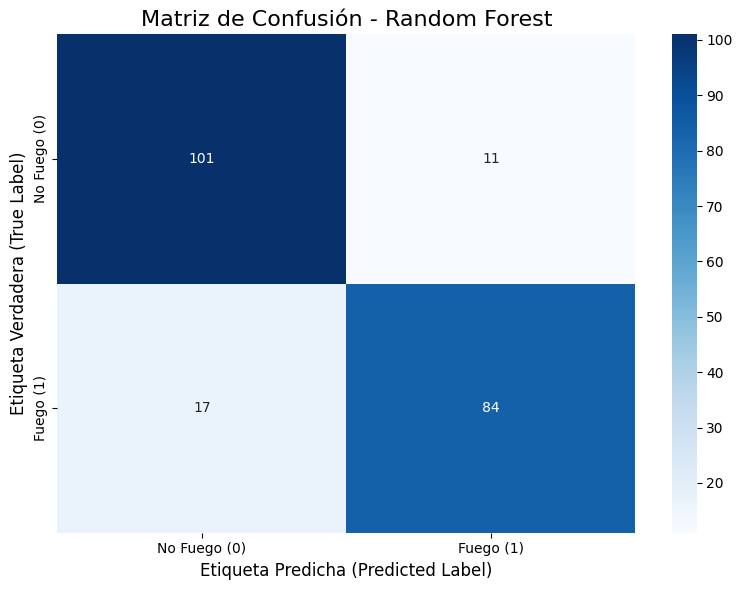

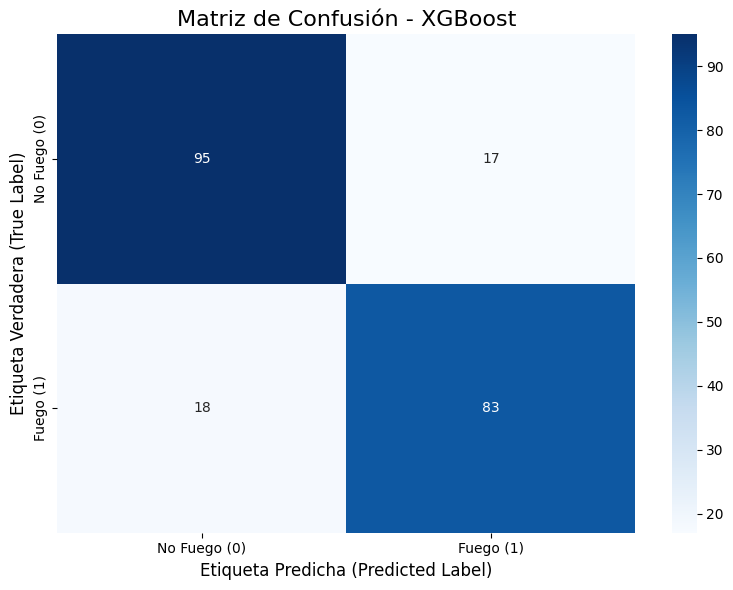

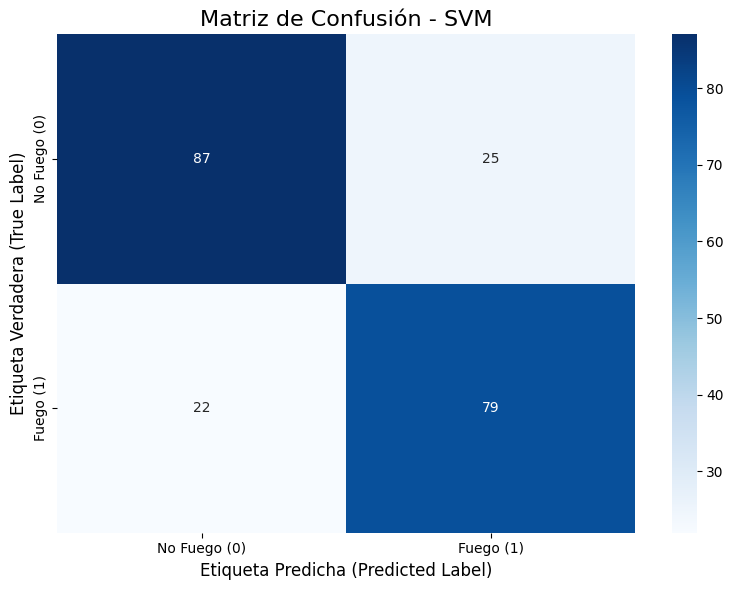

In [105]:
print("\n=== GENERANDO MATRICES DE CONFUSIÓN ===")

# Llamar a la función para cada modelo
plot_confusion_matrix(rf_model, X_test, y_test, "Random Forest")
plot_confusion_matrix(xgb_model, X_test, y_test, "XGBoost")
plot_confusion_matrix(svm_model, X_test, y_test, "SVM", scaled = True)

=== MATRIZ DE PROBABILIDADES DE INCENDIO ===


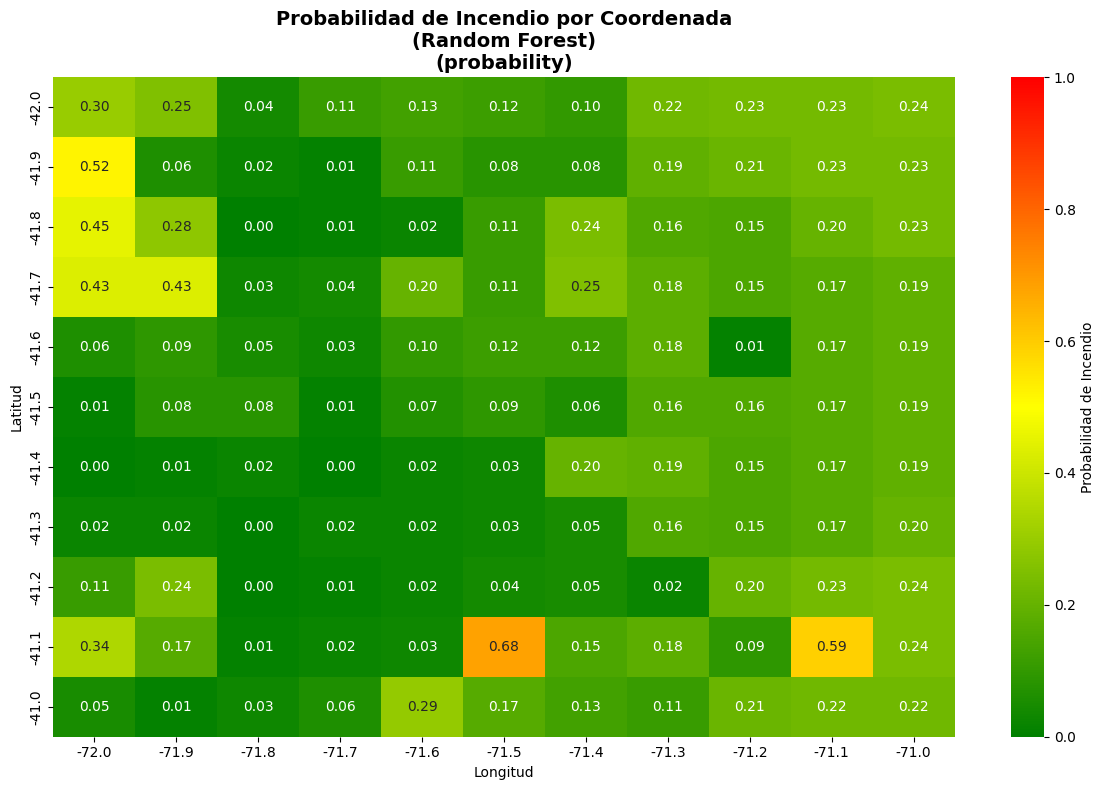

In [97]:
# Usar tu modelo entrenado (ej: Random Forest)
print("=== MATRIZ DE PROBABILIDADES DE INCENDIO ===")
prob_matrix = plot_coordinate_matrix(
    df, 
    rf_model, 
    features, 
    value_type='probability',
    title="Probabilidad de Incendio por Coordenada\n(Random Forest)"
)


=== RANDOM FOREST ===


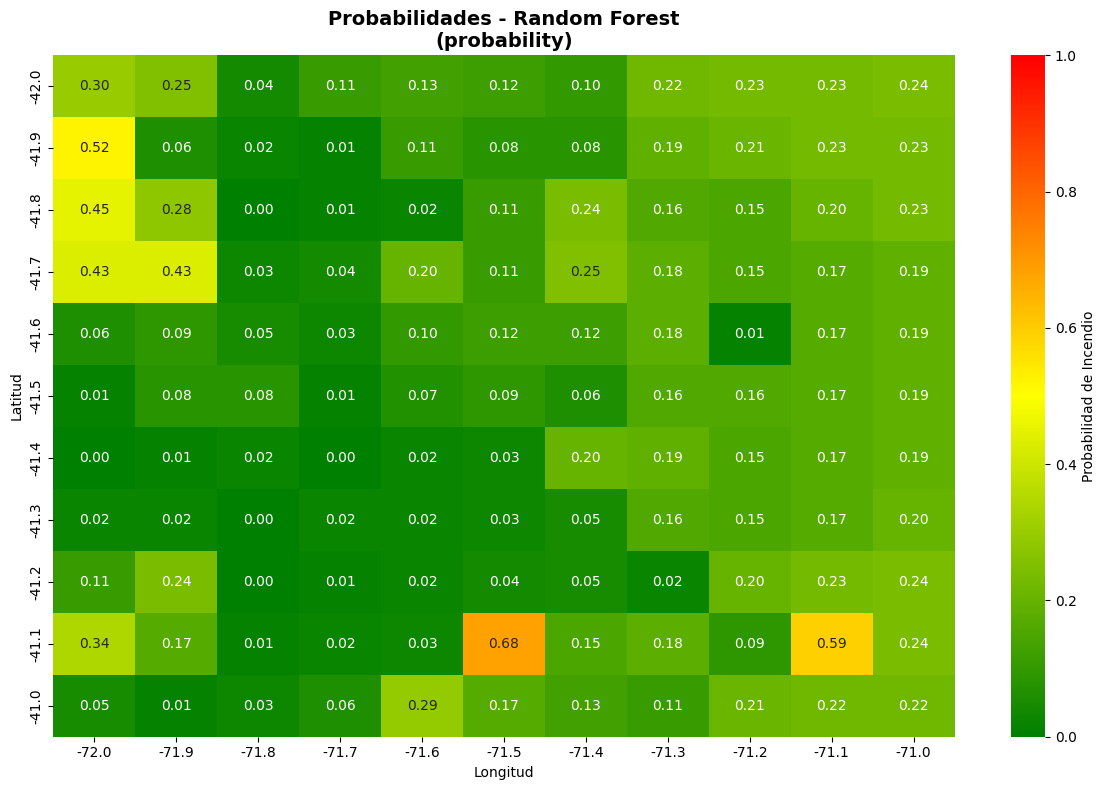


=== XGBOOST ===


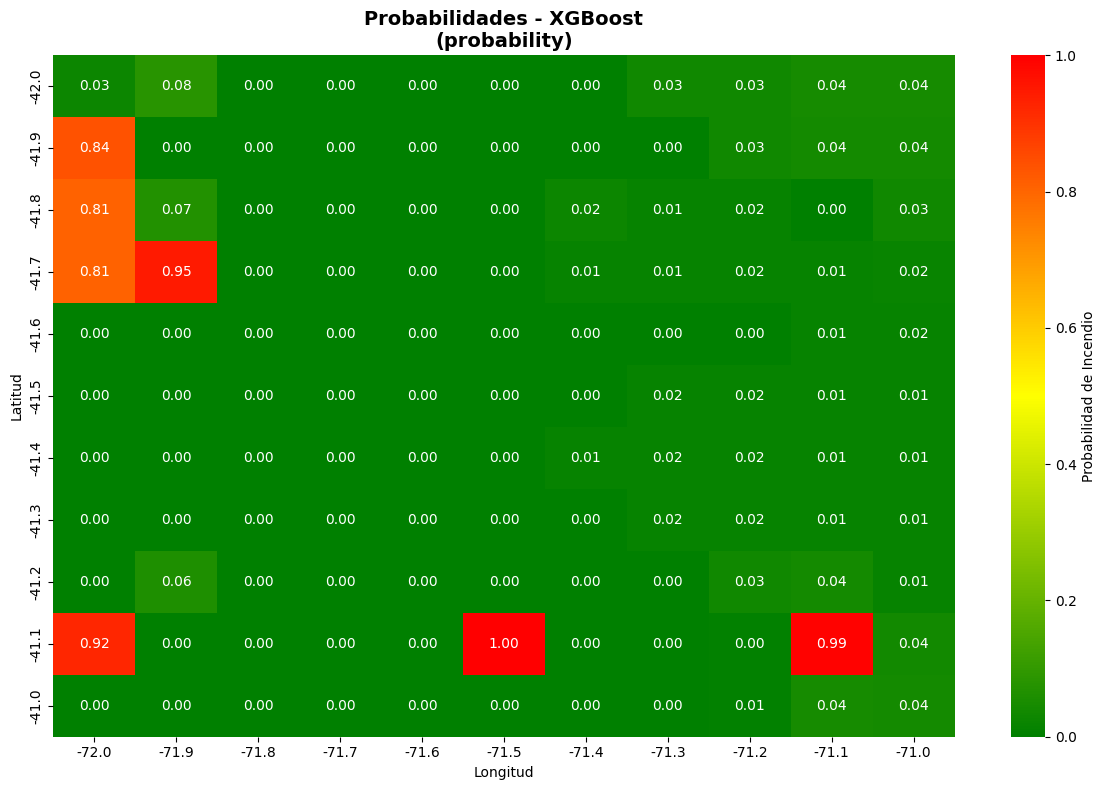


=== SVM ===


C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

C:\Users\Ezequiel\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has f

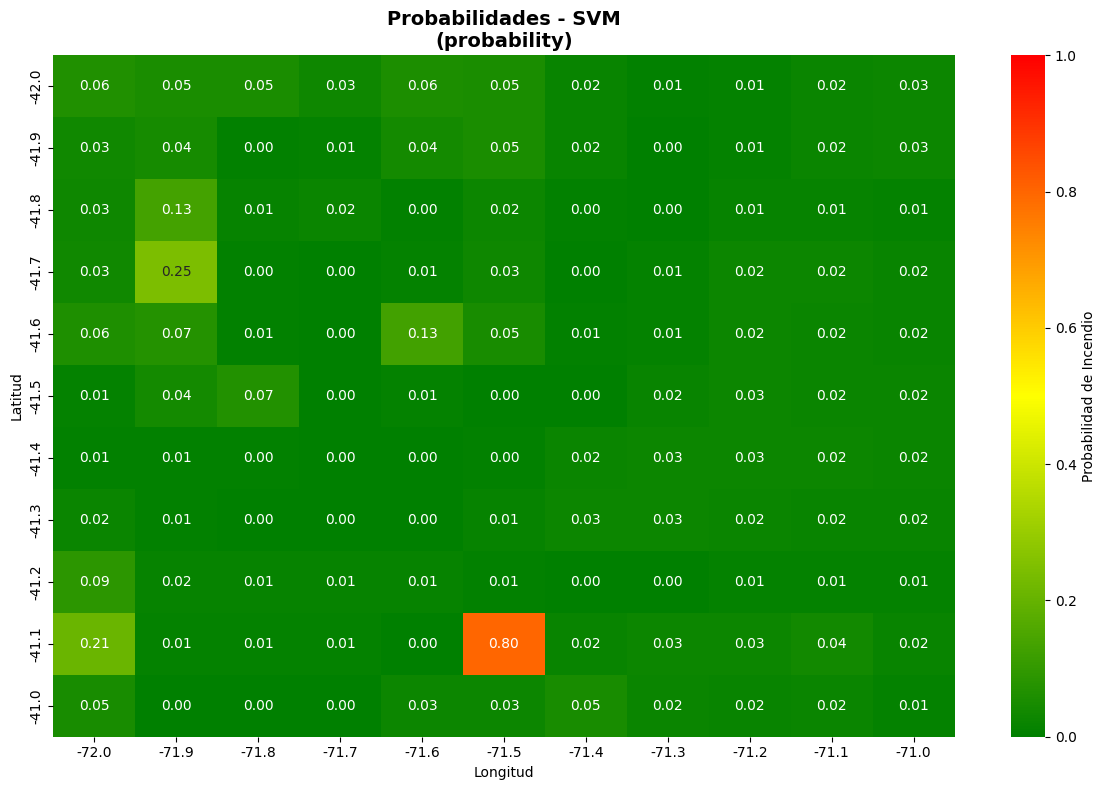

In [101]:
# Comparar diferentes modelos
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'SVM': svm_model
}

for model_name, model in models.items():
    print(f"\n=== {model_name.upper()} ===")
    
    # Para SVM necesitamos escalar los datos
    if model_name == 'SVM':
        # Crear datos escalados para la matriz completa
        df_scaled = df.copy()
        df_scaled[features] = scaler.transform(df[features])
        plot_coordinate_matrix(df_scaled, model, features, 
                             value_type='probability',
                             title=f"Probabilidades - {model_name}")
    else:
        plot_coordinate_matrix(df, model, features, 
                             value_type='probability',
                             title=f"Probabilidades - {model_name}")